In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Supplychaindataset.csv', encoding='latin1')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (5000, 40)
Columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']


In [2]:
print(df.dtypes)
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                   int64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country   

In [4]:
financial_cols = [
    'Sales', 'Order Profit Per Order', 'Benefit per order',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Total', 'Sales per customer', 'Order Item Quantity'
]

df[financial_cols] = df[financial_cols].apply(pd.to_numeric, errors='coerce')
print(df[financial_cols].dtypes)

Sales                       float64
Order Profit Per Order      float64
Benefit per order           float64
Order Item Discount         float64
Order Item Discount Rate    float64
Order Item Product Price    float64
Order Item Profit Ratio     float64
Order Item Total            float64
Sales per customer          float64
Order Item Quantity           int64
dtype: object


In [5]:
before = len(df)
df.dropna(subset=['Sales', 'Order Profit Per Order'], inplace=True)
df = df[df['Sales'] != 0]
df = df[df['Order Item Product Price'] > 0]
print(f"Removed: {before - len(df)} | Remaining: {len(df)}")

Removed: 0 | Remaining: 5000


In [7]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped: {before - len(df)} | Remaining: {len(df)}")

Dropped: 0 | Remaining: 5000


In [6]:
df['Order Item Discount Rate'] = df['Order Item Discount Rate'].clip(0, 1)
print(df['Order Item Discount Rate'].describe())
print(df['Order Item Profit Ratio'].describe())

count    5000.000000
mean        0.130900
std         0.106327
min         0.000000
25%         0.000000
50%         0.100000
75%         0.250000
max         0.300000
Name: Order Item Discount Rate, dtype: float64
count    5000.000000
mean        0.048476
std         0.203289
min        -0.389900
25%        -0.122125
50%         0.062750
75%         0.224800
max         0.448700
Name: Order Item Profit Ratio, dtype: float64


In [8]:
currency_cols = [
    'Sales', 'Order Profit Per Order', 'Benefit per order',
    'Order Item Discount', 'Order Item Product Price',
    'Order Item Total', 'Sales per customer', 'Product Price'
]

df[currency_cols] = df[currency_cols].round(2)
print(df[currency_cols].head())

     Sales  Order Profit Per Order  Benefit per order  Order Item Discount  \
0   163.80                   -6.79              -6.79                40.95   
1   798.30                  111.60             111.60                88.70   
2  1515.29                  405.12             405.12                 0.00   
3   475.02                 -121.25            -121.25               203.58   
4   132.85                   51.18              51.18                 0.00   

   Order Item Product Price  Order Item Total  Sales per customer  \
0                     22.75            163.80             1609.11   
1                     88.70            798.30             5479.89   
2                    216.47           1515.29             5101.18   
3                    113.10            475.02              921.90   
4                    132.85            132.85             6448.58   

   Product Price  
0          22.75  
1          88.70  
2         216.47  
3         113.10  
4         132.85  


In [9]:
from scipy import stats

df['Sales_zscore'] = np.abs(stats.zscore(df['Sales']))
df['is_sales_outlier'] = df['Sales_zscore'] > 3
print("Outliers flagged:", df['is_sales_outlier'].sum())

Outliers flagged: 129


In [10]:
before = len(df)
df = df[(df['Days for shipment (scheduled)'] > 0) & (df['Days for shipping (real)'] >= 0)]
print(f"Removed: {before - len(df)} | Remaining: {len(df)}")

Removed: 0 | Remaining: 5000


In [11]:
print("Records :", len(df))
print("Revenue :", df['Sales'].sum().round(2))
print("Profit  :", df['Order Profit Per Order'].sum().round(2))
print("Margin  :", round(df['Order Profit Per Order'].sum() / df['Sales'].sum() * 100, 2), "%")
print("Nulls   :", df.isnull().sum().sum())
print("Shape   :", df.shape)

df.to_csv('supply_chain_clean.csv', index=False)

Records : 5000
Revenue : 3558970.22
Profit  : 197003.63
Margin  : 5.54 %
Nulls   : 0
Shape   : (5000, 42)


In [12]:
total_revenue = df['Sales'].sum().round(2)
total_profit = df['Order Profit Per Order'].sum().round(2)
profit_margin = round((total_profit / total_revenue) * 100, 2)
avg_order_profit = df['Order Profit Per Order'].mean().round(2)
avg_order_revenue = df['Sales'].mean().round(2)

print("Total Revenue     :", total_revenue)
print("Total Profit      :", total_profit)
print("Profit Margin (%) :", profit_margin)
print("Avg Order Revenue :", avg_order_revenue)
print("Avg Order Profit  :", avg_order_profit)

Total Revenue     : 3558970.22
Total Profit      : 197003.63
Profit Margin (%) : 5.54
Avg Order Revenue : 711.79
Avg Order Profit  : 39.4


In [13]:
status_summary = df.groupby('Order Status').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).round(2)

status_summary['Margin_%'] = (status_summary['Profit'] / status_summary['Revenue'] * 100).round(2)
print(status_summary.sort_values('Revenue', ascending=False))

                 Revenue     Profit  Orders  Margin_%
Order Status                                         
Complete      2508239.13  126007.97    3526      5.02
On Hold        360393.75   24062.78     484      6.68
Pending        349832.99   24900.99     514      7.12
Closed         340504.35   22031.89     476      6.47


In [14]:
shipping_summary = df.groupby('Shipping Mode').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).round(2)

shipping_summary['Margin_%'] = (shipping_summary['Profit'] / shipping_summary['Revenue'] * 100).round(2)
print(shipping_summary.sort_values('Revenue', ascending=False))

                  Revenue    Profit  Orders  Margin_%
Shipping Mode                                        
Same Day        960653.14  52195.31    1328      5.43
Standard Class  895034.62  51555.34    1212      5.76
Second Class    875857.34  45409.92    1235      5.18
First Class     827425.12  47843.06    1225      5.78


In [15]:
market_summary = df.groupby('Market').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).round(2)

market_summary['Margin_%'] = (market_summary['Profit'] / market_summary['Revenue'] * 100).round(2)
print(market_summary.sort_values('Revenue', ascending=False))

                Revenue    Profit  Orders  Margin_%
Market                                             
Africa        836238.14  53260.32    1066      6.37
Pacific Asia  739954.98  49248.07    1091      6.66
USCA          703551.95  35231.05     950      5.01
LATAM         669976.89  35783.80     971      5.34
Europe        609248.26  23480.39     922      3.85


In [16]:
dept_summary = df.groupby('Department Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).round(2)

dept_summary['Margin_%'] = (dept_summary['Profit'] / dept_summary['Revenue'] * 100).round(2)
print(dept_summary.sort_values('Profit', ascending=False))

                    Revenue    Profit  Orders  Margin_%
Department Name                                        
Office Supplies  1092955.02  86986.60     498      7.96
Fashion           242265.24  35621.50     514     14.70
Health            123638.14  23291.10     502     18.84
Sports            230918.21  19274.49     494      8.35
Auto Parts        139527.87  12539.90     537      8.99
Hardware          413508.46  11169.80     469      2.70
Toys              167083.95   9313.91     520      5.57
Home              217771.43   5018.32     502      2.30
Media              80927.77  -1714.66     483     -2.12
Electronics       850374.13  -4497.33     481     -0.53


In [17]:
segment_summary = df.groupby('Customer Segment').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Customers=('Customer Id', 'nunique')
).round(2)

segment_summary['Margin_%'] = (segment_summary['Profit'] / segment_summary['Revenue'] * 100).round(2)
print(segment_summary.sort_values('Profit', ascending=False))

                     Revenue    Profit  Customers  Margin_%
Customer Segment                                           
Corporate         1221292.74  75491.08        259      6.18
Home Office       1122483.24  62481.90        269      5.57
Consumer          1215194.24  59030.65        270      4.86


In [18]:
customer_profit = df.groupby('Customer Id')['Order Profit Per Order'].sum().sort_values(ascending=False)

top_10_pct = int(len(customer_profit) * 0.10)
top_10_profit = customer_profit.iloc[:top_10_pct].sum()
concentration_ratio = round((top_10_profit / total_profit) * 100, 2)

print("Total Customers         :", len(customer_profit))
print("Top 10% Customer Count  :", top_10_pct)
print("Profit from Top 10%     :", round(top_10_profit, 2))
print("Concentration Ratio (%) :", concentration_ratio)

Total Customers         : 798
Top 10% Customer Count  : 79
Profit from Top 10%     : 129878.75
Concentration Ratio (%) : 65.93


In [19]:
product_profit = df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values(ascending=False)

top10_product_profit = product_profit.head(10).sum()
product_concentration = round((top10_product_profit / total_profit) * 100, 2)

print("Top 10 Products Profit      :", round(top10_product_profit, 2))
print("Product Concentration (%)   :", product_concentration)
print()
print(product_profit.head(10))

Top 10 Products Profit      : 129690.82
Product Concentration (%)   : 65.83

Product Name
Conference Table    40727.98
Standing Desk       19211.51
Office Chair Pro    15034.13
Winter Coat         10769.66
Women's Blazer       8556.41
Hair Dryer Pro       8454.23
Bookshelf Unit       7559.69
Men's Jacket         7105.56
Fitness Tracker      6951.30
Dumbbells Set        5320.35
Name: Order Profit Per Order, dtype: float64


In [20]:
loss_orders = df[df['Order Profit Per Order'] < 0]
profit_orders = df[df['Order Profit Per Order'] >= 0]

print("Loss Orders Count     :", len(loss_orders))
print("Profit Orders Count   :", len(profit_orders))
print("Loss Orders Revenue   :", loss_orders['Sales'].sum().round(2))
print("Total Loss Amount     :", loss_orders['Order Profit Per Order'].sum().round(2))
print("Loss Order Share (%)  :", round(len(loss_orders) / len(df) * 100, 2))

Loss Orders Count     : 2115
Profit Orders Count   : 2885
Loss Orders Revenue   : 1436081.9
Total Loss Amount     : -213636.27
Loss Order Share (%)  : 42.3


In [21]:
correlation = df[['Sales', 'Order Profit Per Order']].corr()
high_rev_low_profit = df[(df['Sales'] > df['Sales'].quantile(0.75)) & (df['Order Profit Per Order'] < 0)]

print("Revenue vs Profit Correlation:")
print(correlation)
print()
print("High Revenue but Loss-Making Orders:", len(high_rev_low_profit))
print("Revenue Lost in these Orders       :", high_rev_low_profit['Sales'].sum().round(2))
print("Profit Loss in these Orders        :", high_rev_low_profit['Order Profit Per Order'].sum().round(2))

Revenue vs Profit Correlation:
                          Sales  Order Profit Per Order
Sales                   1.00000                 0.29307
Order Profit Per Order  0.29307                 1.00000

High Revenue but Loss-Making Orders: 484
Revenue Lost in these Orders       : 999692.92
Profit Loss in these Orders        : -146893.72


In [22]:
product_summary = df.groupby('Product Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean')
).round(2)

product_summary['Margin_%'] = (product_summary['Profit'] / product_summary['Revenue'] * 100).round(2)
product_summary = product_summary.sort_values('Profit', ascending=False)
print(product_summary)

                         Revenue    Profit  Orders  Avg_Discount_Rate  \
Product Name                                                            
Conference Table       536759.48  40727.98     117               0.12   
Standing Desk          237895.80  19211.51      93               0.12   
Office Chair Pro       162280.06  15034.13     104               0.13   
Winter Coat             75694.96  10769.66      90               0.14   
Women's Blazer          65193.70   8556.41     111               0.12   
Hair Dryer Pro          45546.93   8454.23     101               0.12   
Bookshelf Unit          84656.45   7559.69      94               0.12   
Men's Jacket            43657.19   7105.56      94               0.11   
Fitness Tracker         72716.05   6951.30      92               0.13   
Dumbbells Set           70467.10   5320.35     107               0.14   
Casual Sneakers         35414.35   5043.28     115               0.13   
Lawn Mower Electric    187973.10   4957.41     111 

In [23]:
category_summary = df.groupby('Category Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean')
).round(2)

category_summary['Margin_%'] = (category_summary['Profit'] / category_summary['Revenue'] * 100).round(2)
category_summary = category_summary.sort_values('Profit', ascending=False)
print(category_summary)

                    Revenue    Profit  Orders  Avg_Discount_Rate  Margin_%
Category Name                                                             
Furniture        1092955.02  86986.60     498               0.12      7.96
Apparel           242265.24  35621.50     514               0.12     14.70
Health & Beauty   123638.14  23291.10     502               0.13     18.84
Sporting Goods    230918.21  19274.49     494               0.13      8.35
Automotive        139527.87  12539.90     537               0.14      8.99
Garden & Tools    413508.46  11169.80     469               0.13      2.70
Toys & Games      167083.95   9313.91     520               0.13      5.57
Home & Kitchen    217771.43   5018.32     502               0.14      2.30
Books              80927.77  -1714.66     483               0.13     -2.12
Technology        850374.13  -4497.33     481               0.14     -0.53


In [24]:
top10_products = product_summary.sort_values('Profit', ascending=False).head(10)
print(top10_products[['Revenue', 'Profit', 'Margin_%', 'Orders']])

                    Revenue    Profit  Margin_%  Orders
Product Name                                           
Conference Table  536759.48  40727.98      7.59     117
Standing Desk     237895.80  19211.51      8.08      93
Office Chair Pro  162280.06  15034.13      9.26     104
Winter Coat        75694.96  10769.66     14.23      90
Women's Blazer     65193.70   8556.41     13.12     111
Hair Dryer Pro     45546.93   8454.23     18.56     101
Bookshelf Unit     84656.45   7559.69      8.93      94
Men's Jacket       43657.19   7105.56     16.28      94
Fitness Tracker    72716.05   6951.30      9.56      92
Dumbbells Set      70467.10   5320.35      7.55     107


In [25]:
bottom10_products = product_summary.sort_values('Profit', ascending=True).head(10)
print(bottom10_products[['Revenue', 'Profit', 'Margin_%', 'Orders']])

                         Revenue   Profit  Margin_%  Orders
Product Name                                               
Monitor 27in           201335.89 -6228.04     -3.09     104
Finance Fundamentals    22540.71  -736.49     -3.27     119
Data Science Handbook   20492.50  -697.62     -3.40      93
Mechanical Keyboard     54536.35  -446.03     -0.82      94
Python Programming      17077.58  -366.37     -2.15     103
Leadership 101           9251.59     5.83      0.06      79
Business Strategy       11565.39    79.99      0.69      89
Pressure Washer         91084.98   206.49      0.23     102
Wireless Mouse          22558.37   266.20      1.18      93
USB-C Hub               36909.56   336.75      0.91      94


In [26]:
rev_threshold = product_summary['Revenue'].quantile(0.75)
margin_threshold = 10

high_rev_low_margin = product_summary[
    (product_summary['Revenue'] >= rev_threshold) &
    (product_summary['Margin_%'] < margin_threshold)
].sort_values('Revenue', ascending=False)

print("High Revenue Low Margin Products:", len(high_rev_low_margin))
print(high_rev_low_margin[['Revenue', 'Profit', 'Margin_%', 'Avg_Discount_Rate']])

High Revenue Low Margin Products: 12
                       Revenue    Profit  Margin_%  Avg_Discount_Rate
Product Name                                                         
Conference Table     536759.48  40727.98      7.59               0.12
Laptop 15in          535033.96   1573.79      0.29               0.13
Standing Desk        237895.80  19211.51      8.08               0.12
Monitor 27in         201335.89  -6228.04     -3.09               0.15
Lawn Mower Electric  187973.10   4957.41      2.64               0.14
Office Chair Pro     162280.06  15034.13      9.26               0.13
Pressure Washer       91084.98    206.49      0.23               0.14
Bookshelf Unit        84656.45   7559.69      8.93               0.12
Tool Set 128pc        79668.14   4301.37      5.40               0.12
Fitness Tracker       72716.05   6951.30      9.56               0.13
Filing Cabinet        71363.23   4453.29      6.24               0.14
Dumbbells Set         70467.10   5320.35      7.55   

In [27]:
high_rev_loss = product_summary[
    (product_summary['Revenue'] >= rev_threshold) &
    (product_summary['Profit'] < 0)
].sort_values('Revenue', ascending=False)

print("High Revenue Loss-Making Products:", len(high_rev_loss))
print(high_rev_loss[['Revenue', 'Profit', 'Margin_%', 'Avg_Discount_Rate']])

High Revenue Loss-Making Products: 1
                Revenue   Profit  Margin_%  Avg_Discount_Rate
Product Name                                                 
Monitor 27in  201335.89 -6228.04     -3.09               0.15


In [28]:
loss_categories = category_summary[category_summary['Profit'] < 0].sort_values('Profit')

print("Loss-Making Categories:", len(loss_categories))
print(loss_categories[['Revenue', 'Profit', 'Margin_%', 'Orders']])

Loss-Making Categories: 2
                 Revenue   Profit  Margin_%  Orders
Category Name                                      
Technology     850374.13 -4497.33     -0.53     481
Books           80927.77 -1714.66     -2.12     483


In [29]:
loss_products = product_summary[product_summary['Profit'] < 0].sort_values('Profit')

print("Total Loss-Making Products:", len(loss_products))
print("Total Loss Amount         :", loss_products['Profit'].sum().round(2))
print(loss_products[['Revenue', 'Profit', 'Margin_%', 'Orders']].head(15))

Total Loss-Making Products: 5
Total Loss Amount         : -8474.55
                         Revenue   Profit  Margin_%  Orders
Product Name                                               
Monitor 27in           201335.89 -6228.04     -3.09     104
Finance Fundamentals    22540.71  -736.49     -3.27     119
Data Science Handbook   20492.50  -697.62     -3.40      93
Mechanical Keyboard     54536.35  -446.03     -0.82      94
Python Programming      17077.58  -366.37     -2.15     103


In [30]:
total_cat_profit = category_summary[category_summary['Profit'] > 0]['Profit'].sum()
category_summary['Profit_Share_%'] = (category_summary['Profit'] / total_cat_profit * 100).round(2)
print(category_summary[['Revenue', 'Profit', 'Margin_%', 'Profit_Share_%']].sort_values('Profit_Share_%', ascending=False))

                    Revenue    Profit  Margin_%  Profit_Share_%
Category Name                                                  
Furniture        1092955.02  86986.60      7.96           42.81
Apparel           242265.24  35621.50     14.70           17.53
Health & Beauty   123638.14  23291.10     18.84           11.46
Sporting Goods    230918.21  19274.49      8.35            9.48
Automotive        139527.87  12539.90      8.99            6.17
Garden & Tools    413508.46  11169.80      2.70            5.50
Toys & Games      167083.95   9313.91      5.57            4.58
Home & Kitchen    217771.43   5018.32      2.30            2.47
Books              80927.77  -1714.66     -2.12           -0.84
Technology        850374.13  -4497.33     -0.53           -2.21


In [31]:
bins = [-float('inf'), 0, 5, 15, float('inf')]
labels = ['Loss', 'Low (0-5%)', 'Mid (5-15%)', 'High (>15%)']
product_summary['Margin_Band'] = pd.cut(product_summary['Margin_%'], bins=bins, labels=labels)
print(product_summary['Margin_Band'].value_counts())

Margin_Band
Mid (5-15%)    23
Low (0-5%)     15
High (>15%)     7
Loss            5
Name: count, dtype: int64


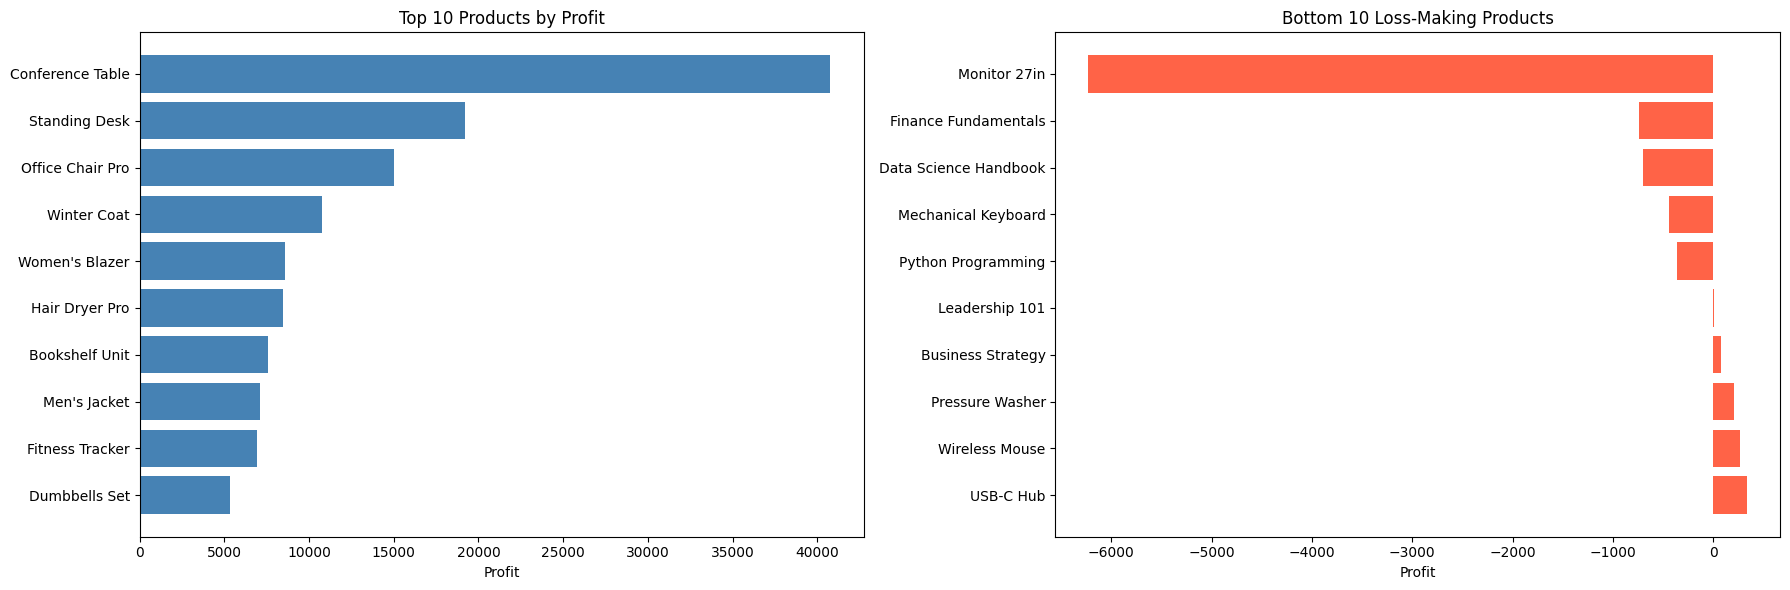

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top10 = product_summary.sort_values('Profit', ascending=False).head(10)
bottom10 = product_summary.sort_values('Profit').head(10)

axes[0].barh(top10.index, top10['Profit'], color='steelblue')
axes[0].set_title('Top 10 Products by Profit')
axes[0].set_xlabel('Profit')
axes[0].invert_yaxis()

axes[1].barh(bottom10.index, bottom10['Profit'], color='tomato')
axes[1].set_title('Bottom 10 Loss-Making Products')
axes[1].set_xlabel('Profit')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

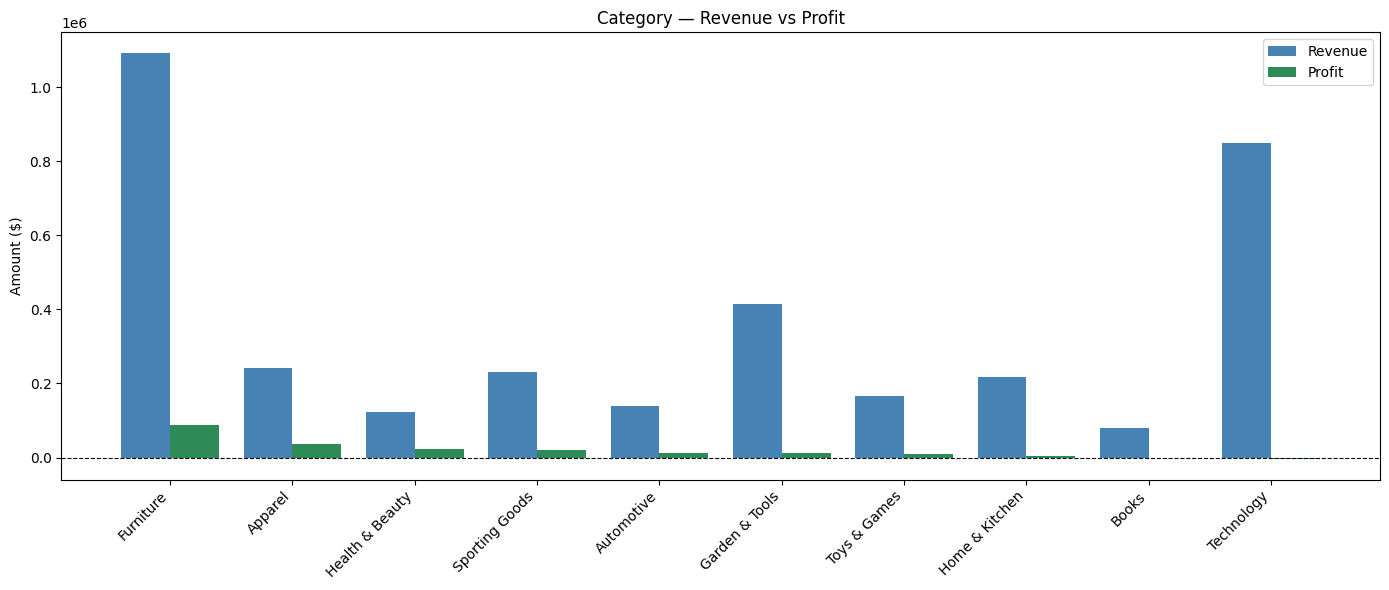

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(category_summary))
width = 0.4

ax.bar([i - width/2 for i in x], category_summary['Revenue'], width=width, label='Revenue', color='steelblue')
ax.bar([i + width/2 for i in x], category_summary['Profit'],  width=width, label='Profit',  color='seagreen')

ax.set_xticks(list(x))
ax.set_xticklabels(category_summary.index, rotation=45, ha='right')
ax.set_title('Category — Revenue vs Profit')
ax.set_ylabel('Amount ($)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

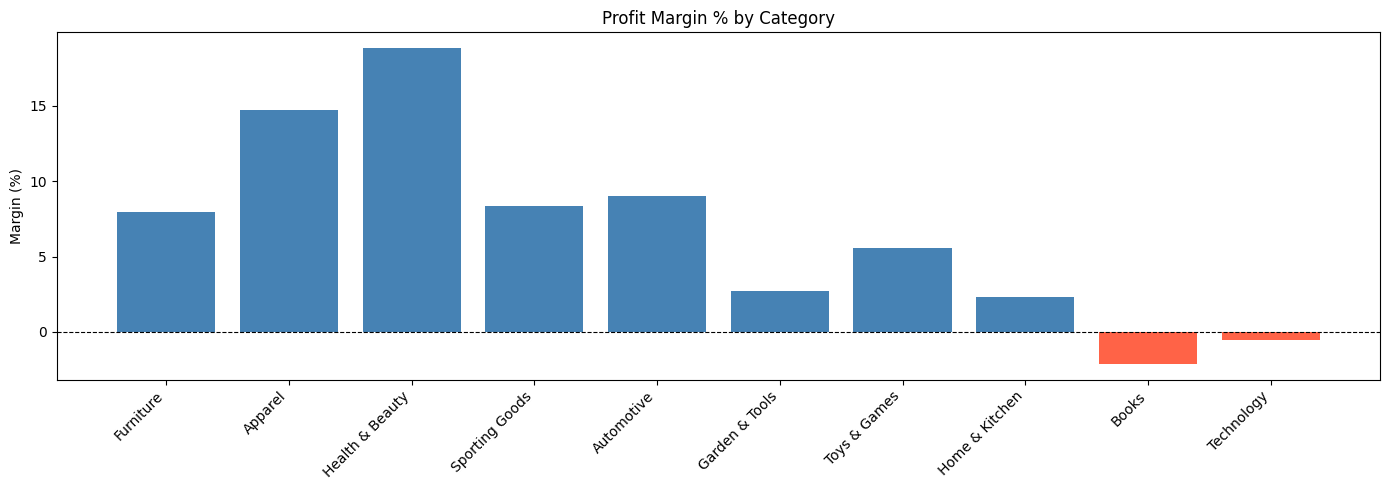

In [34]:
colors = ['tomato' if m < 0 else 'steelblue' for m in category_summary['Margin_%']]

plt.figure(figsize=(14, 5))
plt.bar(category_summary.index, category_summary['Margin_%'], color=colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Profit Margin % by Category')
plt.ylabel('Margin (%)')
plt.tight_layout()
plt.show()

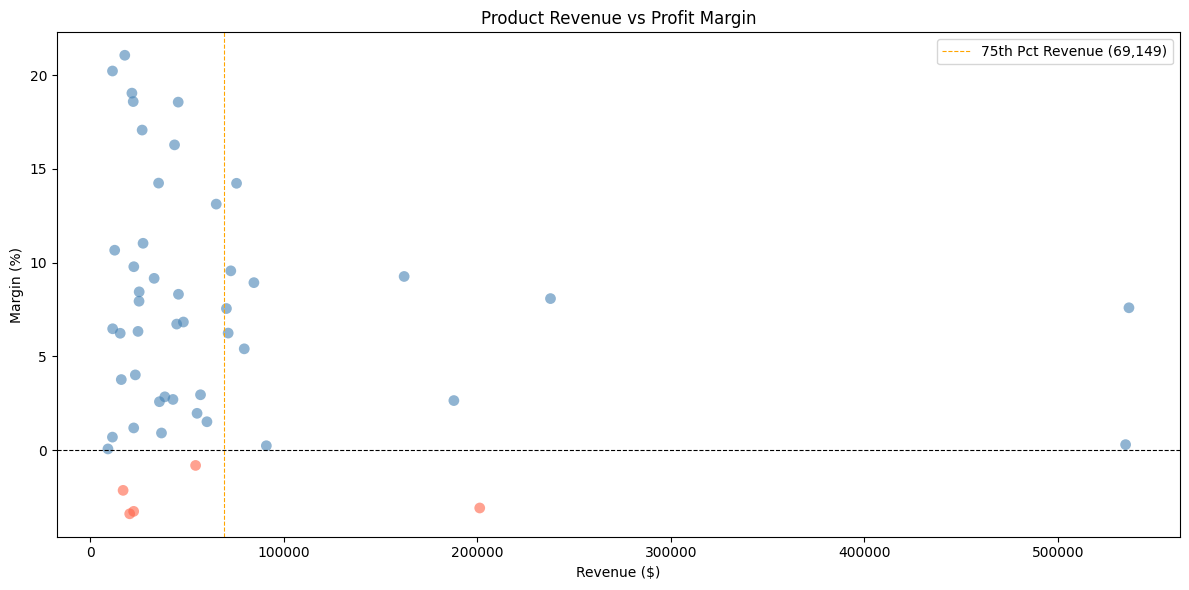

In [35]:
plt.figure(figsize=(12, 6))

colors = product_summary['Margin_%'].apply(lambda x: 'tomato' if x < 0 else 'steelblue')

plt.scatter(product_summary['Revenue'], product_summary['Margin_%'], c=colors, alpha=0.6, edgecolors='none', s=60)
plt.axhline(0,  color='black', linewidth=0.8, linestyle='--')
plt.axvline(rev_threshold, color='orange', linewidth=0.8, linestyle='--', label=f'75th Pct Revenue ({rev_threshold:,.0f})')
plt.title('Product Revenue vs Profit Margin')
plt.xlabel('Revenue ($)')
plt.ylabel('Margin (%)')
plt.legend()
plt.tight_layout()
plt.show()

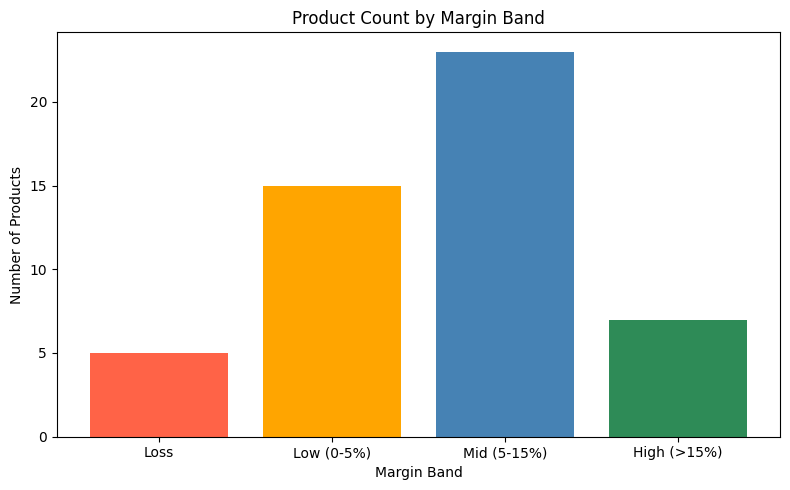

In [36]:
band_counts = product_summary['Margin_Band'].value_counts().reindex(['Loss', 'Low (0-5%)', 'Mid (5-15%)', 'High (>15%)'])
colors = ['tomato', 'orange', 'steelblue', 'seagreen']

plt.figure(figsize=(8, 5))
plt.bar(band_counts.index, band_counts.values, color=colors)
plt.title('Product Count by Margin Band')
plt.xlabel('Margin Band')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

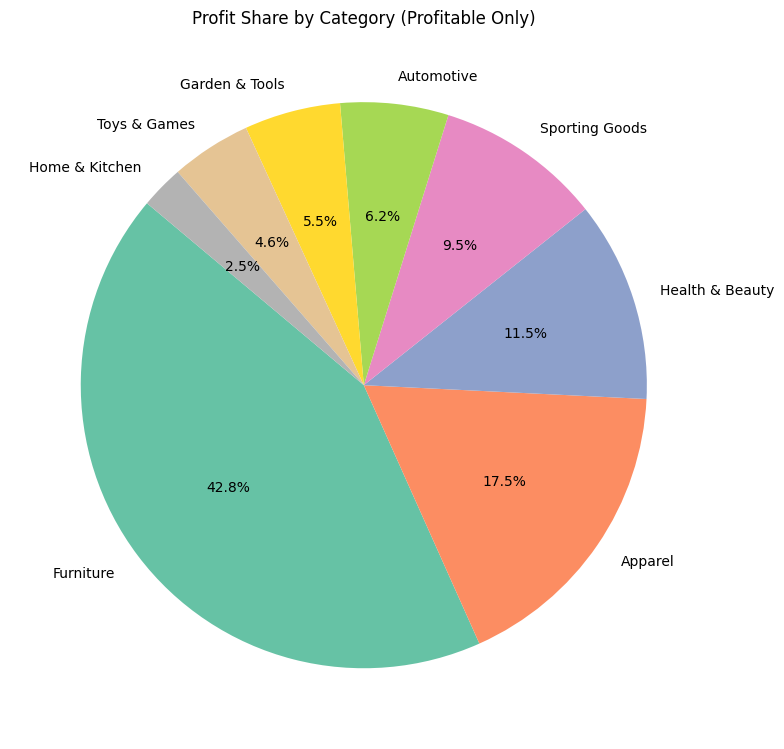

In [37]:
pos_categories = category_summary[category_summary['Profit'] > 0]

plt.figure(figsize=(8, 8))
plt.pie(
    pos_categories['Profit'],
    labels=pos_categories.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(pos_categories))
)
plt.title('Profit Share by Category (Profitable Only)')
plt.tight_layout()
plt.show()

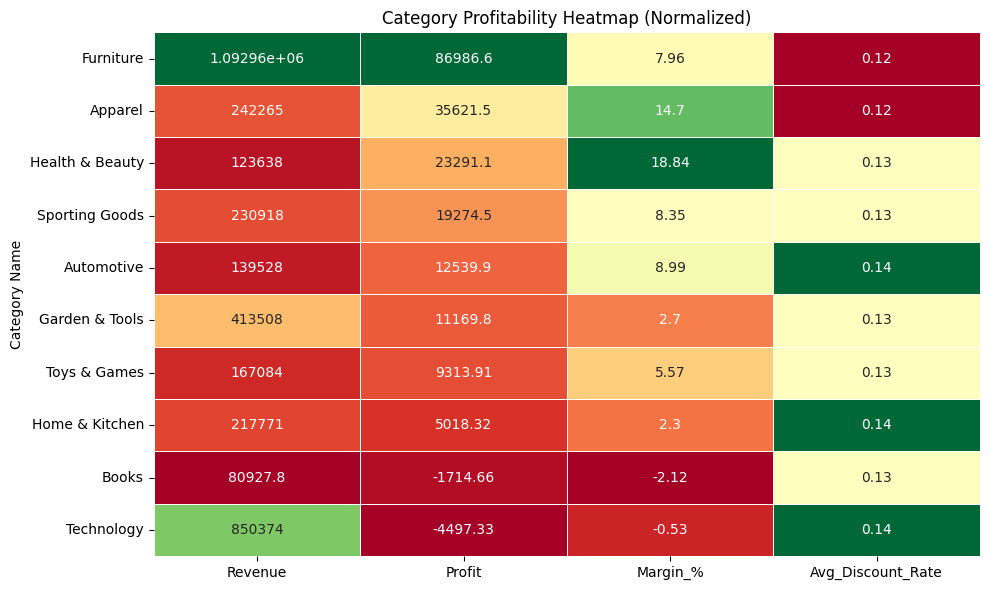

In [38]:
heat_data = category_summary[['Revenue', 'Profit', 'Margin_%', 'Avg_Discount_Rate']].copy()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heat_data.apply(lambda x: (x - x.min()) / (x.max() - x.min())),
    annot=heat_data.round(2),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar=False
)
plt.title('Category Profitability Heatmap (Normalized)')
plt.tight_layout()
plt.show()

In [39]:
customer_summary = df.groupby('Customer Id').agg(
    Customer_Name=('Customer Fname', 'first'),
    Segment=('Customer Segment', 'first'),
    Market=('Market', 'first'),
    Country=('Customer Country', 'first'),
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Total_Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean')
).round(2)

customer_summary['Margin_%'] = (customer_summary['Total_Profit'] / customer_summary['Total_Revenue'] * 100).round(2)
customer_summary = customer_summary.sort_values('Total_Profit', ascending=False)
print("Total Customers:", len(customer_summary))
print(customer_summary.head(10))

Total Customers: 798
            Customer_Name      Segment        Market        Country  \
Customer Id                                                           
1520              Charles    Corporate          USCA         Canada   
1492              Dorothy     Consumer        Europe          Italy   
1045              Richard  Home Office        Africa          Ghana   
1093               Daniel     Consumer  Pacific Asia      Australia   
1334              Michael    Corporate          USCA         Canada   
1559                Maria    Corporate        Africa   South Africa   
1273                Linda    Corporate          USCA  United States   
1800              Michael     Consumer          USCA  United States   
1632              Richard    Corporate  Pacific Asia      Australia   
1250                Karen    Corporate        Europe          Italy   

             Total_Revenue  Total_Profit  Total_Orders  Avg_Discount_Rate  \
Customer Id                                      

In [41]:
top_customers = customer_summary.sort_values('Total_Profit', ascending=False).head(20)
print("Top 20 High-Value Customers:")
print(top_customers[['Customer_Name', 'Segment', 'Market', 'Total_Revenue', 'Total_Profit', 'Margin_%', 'Total_Orders']])

Top 20 High-Value Customers:
            Customer_Name      Segment        Market  Total_Revenue  \
Customer Id                                                           
1520              Charles    Corporate          USCA       10974.13   
1492              Dorothy     Consumer        Europe       14212.69   
1045              Richard  Home Office        Africa       12524.10   
1093               Daniel     Consumer  Pacific Asia       13387.70   
1334              Michael    Corporate          USCA       16965.10   
1559                Maria    Corporate        Africa       13635.92   
1273                Linda    Corporate          USCA       11132.63   
1800              Michael     Consumer          USCA       10822.67   
1632              Richard    Corporate  Pacific Asia       13900.65   
1250                Karen    Corporate        Europe        9323.60   
1070               Sandra     Consumer        Africa       13319.19   
1059              Barbara    Corporate          

In [42]:
low_margin = customer_summary[
    (customer_summary['Total_Profit'] >= 0) &
    (customer_summary['Margin_%'] < 5)
].sort_values('Margin_%')

print("Low-Margin Customers (0% to 5%):", len(low_margin))
print(low_margin[['Customer_Name', 'Segment', 'Total_Revenue', 'Total_Profit', 'Margin_%', 'Avg_Discount_Rate']].head(15))

Low-Margin Customers (0% to 5%): 122
            Customer_Name      Segment  Total_Revenue  Total_Profit  Margin_%  \
Customer Id                                                                     
1284              Jessica     Consumer        2518.03          0.30      0.01   
1361               Thomas    Corporate        4054.48          3.82      0.09   
1480              Barbara    Corporate        3447.24          6.66      0.19   
1568                Susan     Consumer        9182.78         18.21      0.20   
1598                Linda  Home Office        1207.07          2.90      0.24   
1683              Jessica    Corporate        1475.65          3.68      0.25   
1464                 Mark     Consumer        5021.46         13.24      0.26   
1656                Betty  Home Office        1916.79          5.32      0.28   
1230                Susan  Home Office        1049.23          3.03      0.29   
1106                Linda  Home Office        3369.50         10.28     

In [43]:
loss_customers = customer_summary[customer_summary['Total_Profit'] < 0].sort_values('Total_Profit')

print("Total Loss-Making Customers    :", len(loss_customers))
print("Total Loss Amount              :", loss_customers['Total_Profit'].sum().round(2))
print("Loss Customer Share (%)        :", round(len(loss_customers) / len(customer_summary) * 100, 2))
print()
print(loss_customers[['Customer_Name', 'Segment', 'Market', 'Total_Revenue', 'Total_Profit', 'Margin_%', 'Avg_Discount_Rate']].head(15))

Total Loss-Making Customers    : 233
Total Loss Amount              : -90490.98
Loss Customer Share (%)        : 29.2

            Customer_Name      Segment        Market  Total_Revenue  \
Customer Id                                                           
1146               Robert    Corporate          USCA       16042.87   
1033               Donald    Corporate        Europe       10348.00   
1600                Karen     Consumer          USCA       12047.07   
1647               Thomas     Consumer        Europe        9302.48   
1496              William    Corporate         LATAM        7485.64   
1007                Susan  Home Office  Pacific Asia       11510.14   
1618              Charles    Corporate        Europe        9327.56   
1120              Matthew     Consumer          USCA       14464.43   
1437              Charles     Consumer  Pacific Asia        9860.72   
1687                Linda  Home Office        Europe       18293.53   
1016                Sarah    

In [44]:
def assign_tier(row):
    if row['Total_Profit'] >= 500:
        return 'Platinum'
    elif row['Total_Profit'] >= 200:
        return 'Gold'
    elif row['Total_Profit'] >= 0:
        return 'Silver'
    else:
        return 'Loss'

customer_summary['Value_Tier'] = customer_summary.apply(assign_tier, axis=1)

tier_summary = customer_summary.groupby('Value_Tier').agg(
    Customers=('Total_Revenue', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Total_Profit=('Total_Profit', 'sum'),
    Avg_Margin=('Margin_%', 'mean')
).round(2)

print(tier_summary)

            Customers  Total_Revenue  Total_Profit  Avg_Margin
Value_Tier                                                    
Gold              169      565891.85      57204.01       12.31
Loss              233     1068392.16     -90490.98       -8.35
Platinum          199     1418179.94     212092.62       15.92
Silver            197      506506.27      18197.98        6.56


In [45]:
tier_segment = customer_summary.groupby(['Customer Segment' if 'Customer Segment' in customer_summary.columns else 'Segment', 'Value_Tier']).size().unstack(fill_value=0)
print(tier_segment)

Value_Tier   Gold  Loss  Platinum  Silver
Segment                                  
Consumer       67    89        64      50
Corporate      41    73        77      68
Home Office    61    71        58      79


In [46]:
sorted_profit = customer_summary['Total_Profit'].sort_values(ascending=False)
cumulative_profit = sorted_profit.cumsum()
cumulative_pct = cumulative_profit / sorted_profit.sum() * 100
customer_pct = range(1, len(sorted_profit) + 1)

top20_idx = int(len(sorted_profit) * 0.20)
print("Top 20% Customers Count     :", top20_idx)
print("Profit from Top 20%         :", sorted_profit.iloc[:top20_idx].sum().round(2))
print("Concentration Ratio (%)     :", cumulative_pct.iloc[top20_idx - 1].round(2))

Top 20% Customers Count     : 159
Profit from Top 20%         : 190451.75
Concentration Ratio (%)     : 96.67


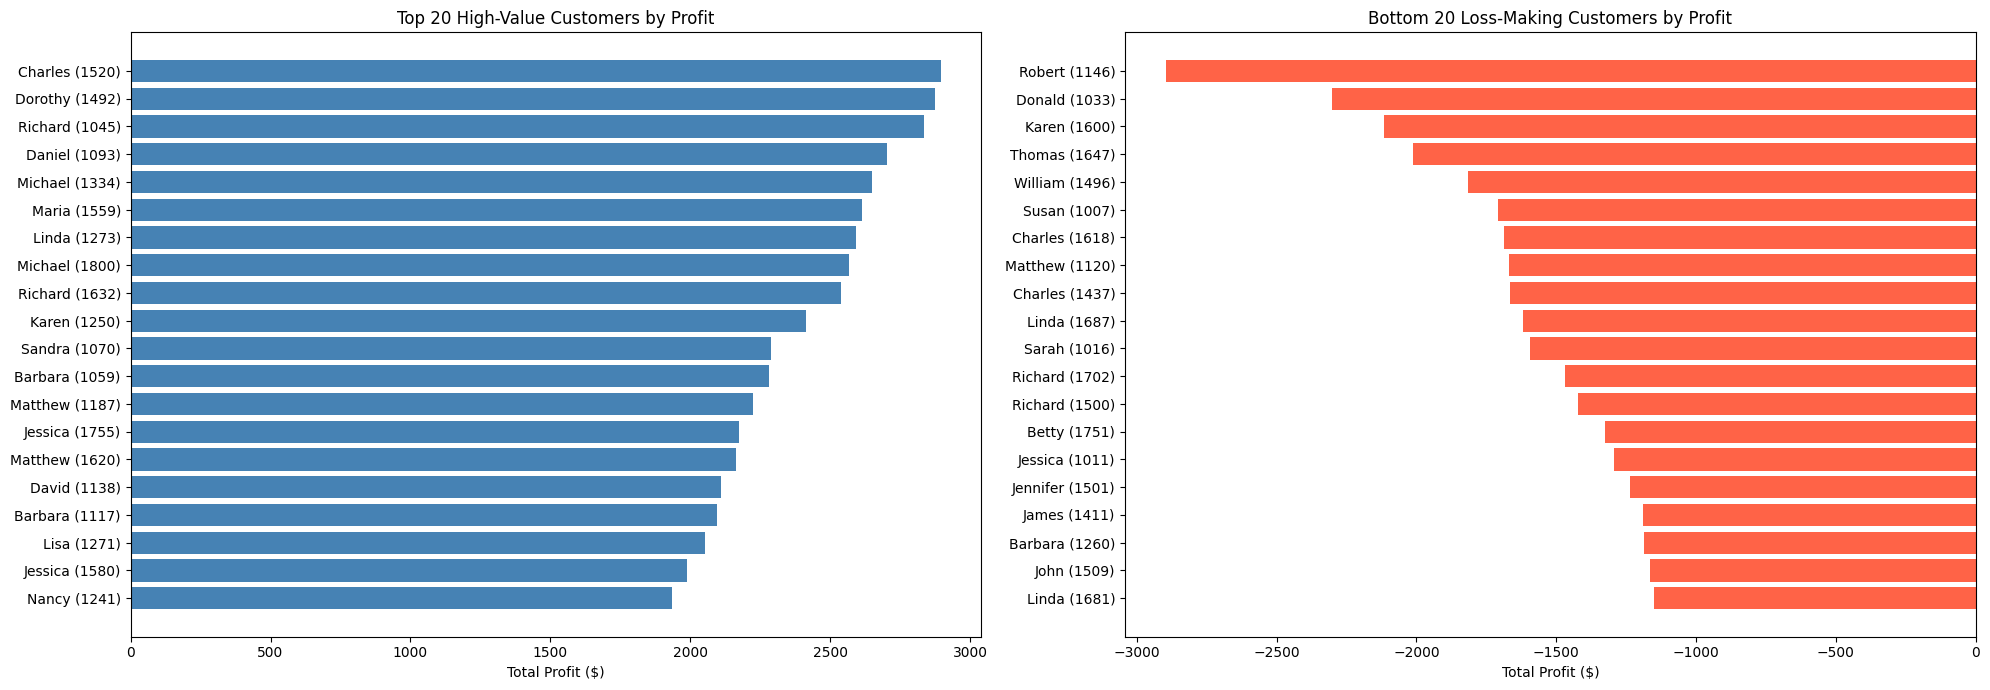

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

top20 = customer_summary.sort_values('Total_Profit', ascending=False).head(20)
bottom20 = customer_summary.sort_values('Total_Profit').head(20)

axes[0].barh(top20['Customer_Name'] + ' (' + top20.index.astype(str) + ')', top20['Total_Profit'], color='steelblue')
axes[0].set_title('Top 20 High-Value Customers by Profit')
axes[0].set_xlabel('Total Profit ($)')
axes[0].invert_yaxis()

axes[1].barh(bottom20['Customer_Name'] + ' (' + bottom20.index.astype(str) + ')', bottom20['Total_Profit'], color='tomato')
axes[1].set_title('Bottom 20 Loss-Making Customers by Profit')
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

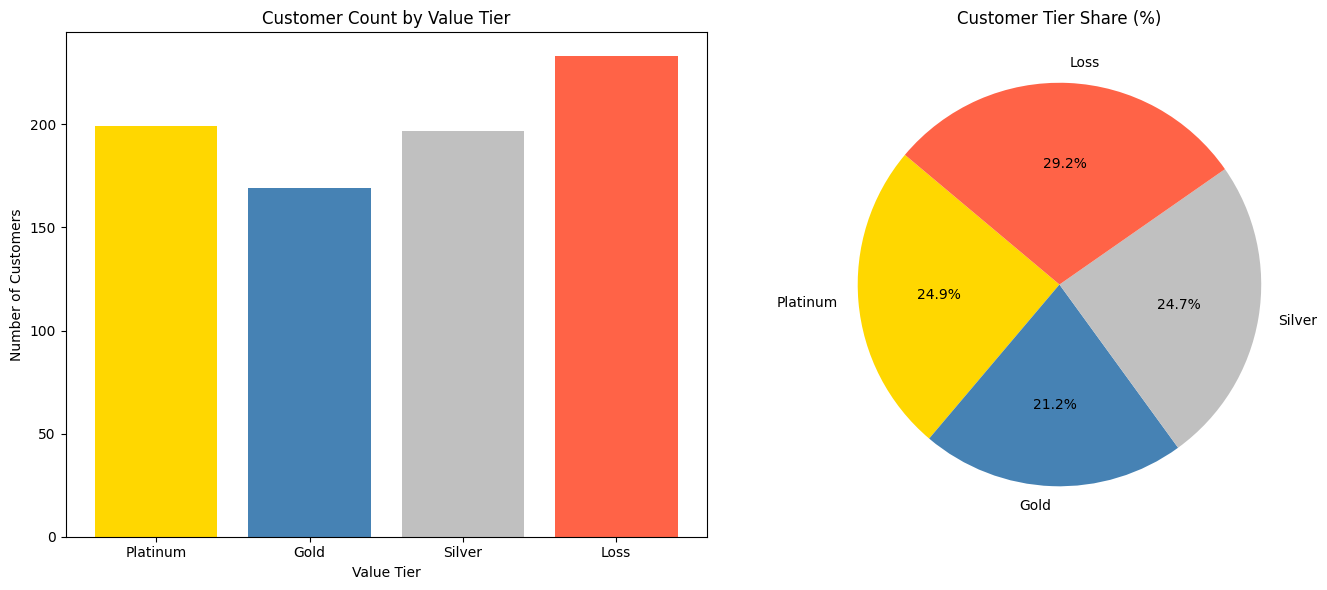

In [48]:
tier_order = ['Platinum', 'Gold', 'Silver', 'Loss']
tier_colors = ['gold', 'steelblue', 'silver', 'tomato']
tier_counts = customer_summary['Value_Tier'].value_counts().reindex(tier_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(tier_counts.index, tier_counts.values, color=tier_colors)
axes[0].set_title('Customer Count by Value Tier')
axes[0].set_xlabel('Value Tier')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=tier_colors,
    startangle=140
)
axes[1].set_title('Customer Tier Share (%)')

plt.tight_layout()
plt.show()

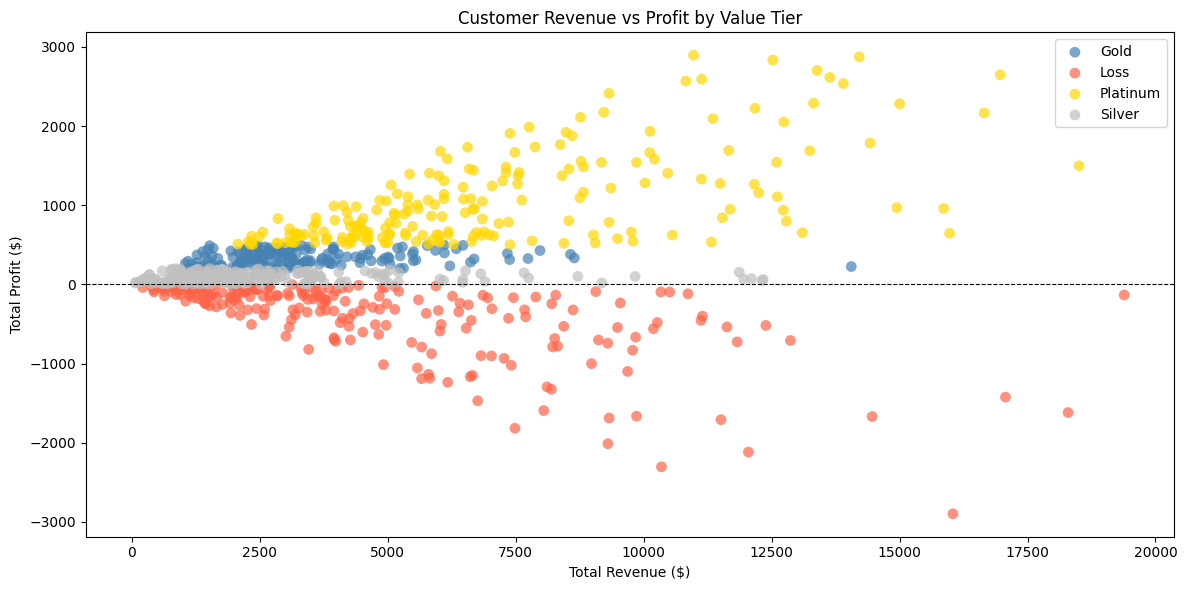

In [49]:
tier_palette = {'Platinum': 'gold', 'Gold': 'steelblue', 'Silver': 'silver', 'Loss': 'tomato'}

plt.figure(figsize=(12, 6))
for tier, group in customer_summary.groupby('Value_Tier'):
    plt.scatter(group['Total_Revenue'], group['Total_Profit'],
                label=tier, color=tier_palette[tier], alpha=0.7, s=60, edgecolors='none')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Customer Revenue vs Profit by Value Tier')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Total Profit ($)')
plt.legend()
plt.tight_layout()
plt.show()

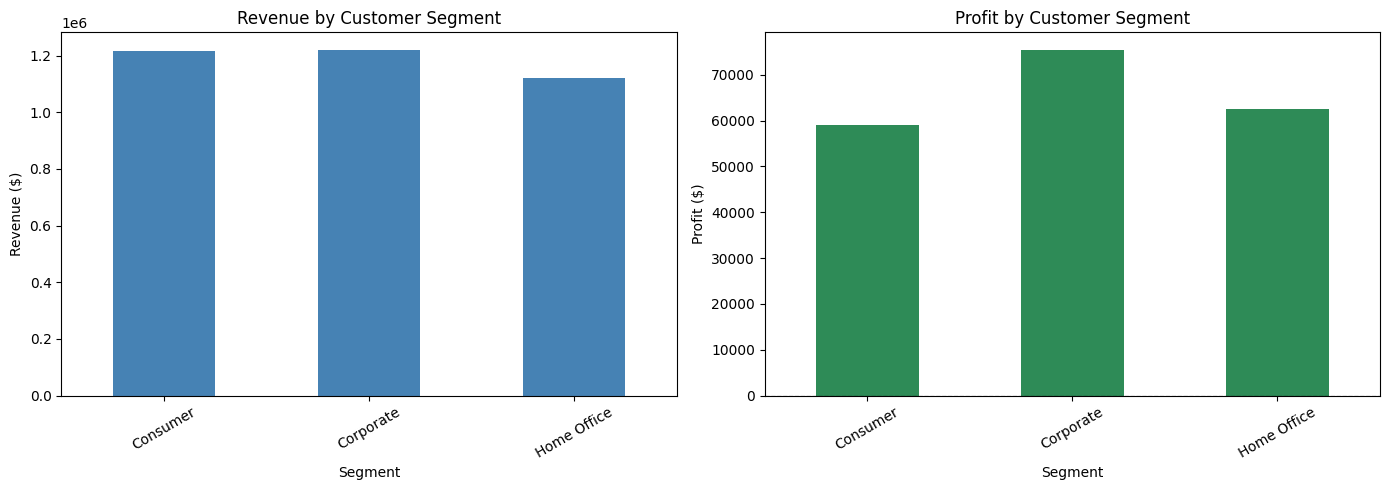

In [50]:
seg_profit = customer_summary.groupby('Segment')[['Total_Revenue', 'Total_Profit']].sum().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_profit['Total_Revenue'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue by Customer Segment')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

seg_profit['Total_Profit'].plot(kind='bar', ax=axes[1], color=['seagreen' if v >= 0 else 'tomato' for v in seg_profit['Total_Profit']])
axes[1].set_title('Profit by Customer Segment')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

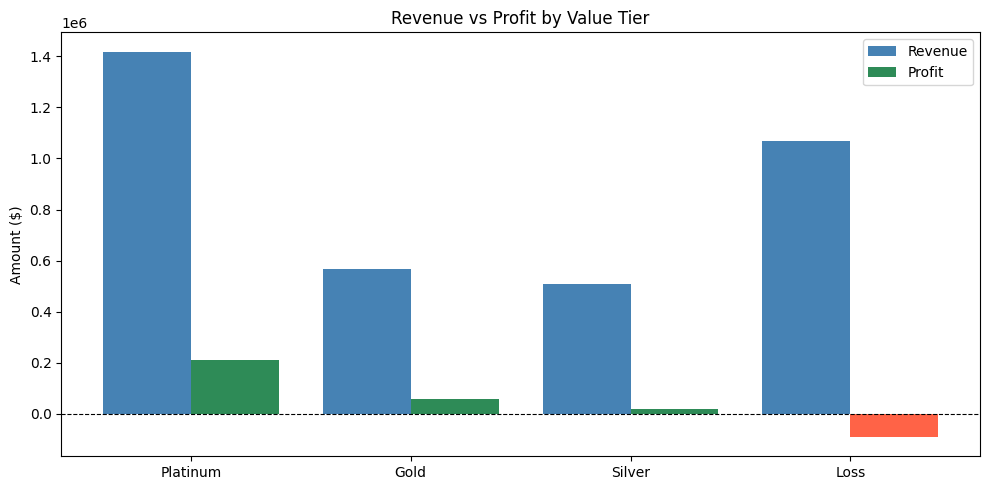

In [51]:
tier_agg = customer_summary.groupby('Value_Tier')[['Total_Revenue', 'Total_Profit']].sum().reindex(tier_order)

x = range(len(tier_agg))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], tier_agg['Total_Revenue'], width=width, label='Revenue', color='steelblue')
ax.bar([i + width/2 for i in x], tier_agg['Total_Profit'],  width=width, label='Profit',  color=['seagreen' if v >= 0 else 'tomato' for v in tier_agg['Total_Profit']])
ax.set_xticks(list(x))
ax.set_xticklabels(tier_agg.index)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Revenue vs Profit by Value Tier')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

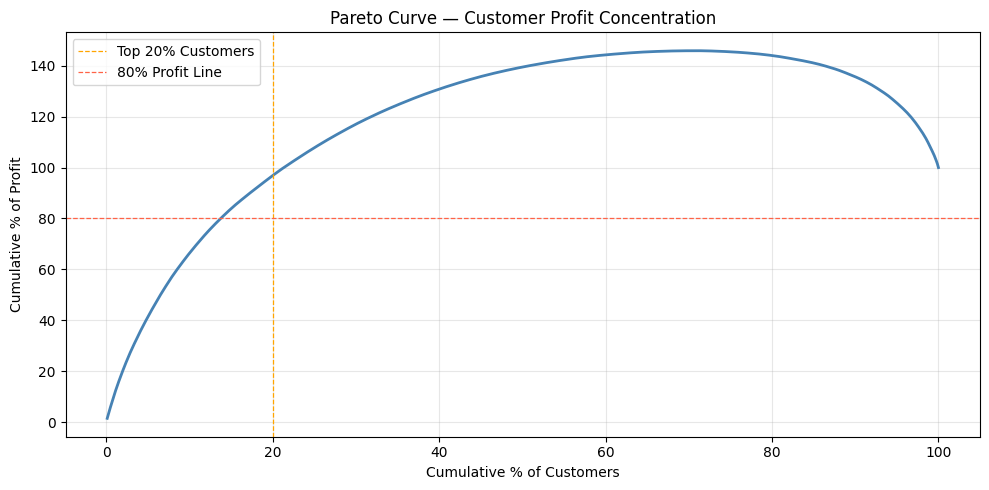

In [52]:
sorted_profit = customer_summary['Total_Profit'].sort_values(ascending=False).reset_index(drop=True)
cumulative_pct = (sorted_profit.cumsum() / sorted_profit.sum() * 100)
customer_pct = (sorted_profit.index + 1) / len(sorted_profit) * 100

plt.figure(figsize=(10, 5))
plt.plot(customer_pct, cumulative_pct, color='steelblue', linewidth=2)
plt.axvline(20, color='orange', linestyle='--', linewidth=0.9, label='Top 20% Customers')
plt.axhline(80, color='tomato',  linestyle='--', linewidth=0.9, label='80% Profit Line')
plt.title('Pareto Curve — Customer Profit Concentration')
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
df['Has_Discount'] = df['Order Item Discount Rate'].apply(lambda x: 'With Discount' if x > 0 else 'No Discount')

discount_compare = df.groupby('Has_Discount').agg(
    Orders=('Sales', 'count'),
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(2)

discount_compare['Margin_%'] = (discount_compare['Total_Profit'] / discount_compare['Total_Revenue'] * 100).round(2)
print(discount_compare)

               Orders  Total_Revenue  Total_Profit  Avg_Discount_Rate  \
Has_Discount                                                            
No Discount      1266     1025866.38     275920.23               0.00   
With Discount    3734     2533103.84     -78916.60               0.18   

               Avg_Profit_Ratio  Margin_%  
Has_Discount                               
No Discount                0.28     26.90  
With Discount             -0.03     -3.12  


In [54]:
bins   = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 1.0]
labels = ['0-5%', '5-10%', '10-20%', '20-30%', '30-40%', '40%+']

df['Discount_Band'] = pd.cut(df['Order Item Discount Rate'], bins=bins, labels=labels, include_lowest=True)

band_summary = df.groupby('Discount_Band', observed=False).agg(
    Orders=('Sales', 'count'),
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(2)

band_summary['Margin_%'] = (band_summary['Total_Profit'] / band_summary['Total_Revenue'] * 100).round(2)
print(band_summary)

               Orders  Total_Revenue  Total_Profit  Avg_Profit_Ratio  Margin_%
Discount_Band                                                                 
0-5%             1893     1497452.29     360359.87              0.26     24.06
5-10%             635      458668.53      41098.72              0.11      8.96
10-20%           1205      883764.79     -43448.70             -0.03     -4.92
20-30%           1267      719084.61    -161006.26             -0.21    -22.39
30-40%              0           0.00          0.00               NaN       NaN
40%+                0           0.00          0.00               NaN       NaN


In [55]:
correlation = df[['Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Profit Per Order', 'Sales']].corr().round(3)
print("Correlation Matrix:")
print(correlation)

disc_profit_corr = df['Order Item Discount Rate'].corr(df['Order Item Profit Ratio'])
print("\nDiscount Rate vs Profit Ratio Correlation:", round(disc_profit_corr, 4))

Correlation Matrix:
                          Order Item Discount Rate  Order Item Profit Ratio  \
Order Item Discount Rate                     1.000                   -0.947   
Order Item Profit Ratio                     -0.947                    1.000   
Order Profit Per Order                      -0.486                    0.486   
Sales                                       -0.069                    0.019   

                          Order Profit Per Order  Sales  
Order Item Discount Rate                  -0.486 -0.069  
Order Item Profit Ratio                    0.486  0.019  
Order Profit Per Order                     1.000  0.293  
Sales                                      0.293  1.000  

Discount Rate vs Profit Ratio Correlation: -0.9475


In [56]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
erosion_data = []

for t in thresholds:
    above = df[df['Order Item Discount Rate'] >= t]
    below = df[df['Order Item Discount Rate'] <  t]
    erosion_data.append({
        'Threshold': f'>={int(t*100)}%',
        'Orders_Above': len(above),
        'Revenue_Above': above['Sales'].sum().round(2),
        'Profit_Above': above['Order Profit Per Order'].sum().round(2),
        'Margin_Above_%': round(above['Order Profit Per Order'].sum() / above['Sales'].sum() * 100, 2) if above['Sales'].sum() > 0 else 0,
        'Margin_Below_%': round(below['Order Profit Per Order'].sum() / below['Sales'].sum() * 100, 2) if below['Sales'].sum() > 0 else 0
    })

erosion_df = pd.DataFrame(erosion_data)
print(erosion_df)

  Threshold  Orders_Above  Revenue_Above  Profit_Above  Margin_Above_%  \
0      >=5%          3734     2533103.84     -78916.60           -3.12   
1     >=10%          3107     2061517.93    -163356.24           -7.92   
2     >=15%          2472     1602849.40    -204454.96          -12.76   
3     >=20%          1888     1165205.65    -201585.13          -17.30   
4     >=25%          1267      719084.61    -161006.26          -22.39   
5     >=30%           622      321882.32     -87648.50          -27.23   
6     >=35%             0           0.00          0.00            0.00   
7     >=40%             0           0.00          0.00            0.00   

   Margin_Below_%  
0           26.90  
1           24.06  
2           20.52  
3           16.65  
4           12.61  
5            8.79  
6            5.54  
7            5.54  


In [57]:
cat_discount = df.groupby('Category Name').agg(
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Total_Revenue=('Sales', 'sum'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(3)

cat_discount['Margin_%'] = (cat_discount['Total_Profit'] / cat_discount['Total_Revenue'] * 100).round(2)
cat_discount = cat_discount.sort_values('Avg_Discount_Rate', ascending=False)
print(cat_discount)

                 Avg_Discount_Rate  Total_Profit  Total_Revenue  \
Category Name                                                     
Home & Kitchen               0.138       5018.32      217771.43   
Technology                   0.138      -4497.33      850374.13   
Automotive                   0.137      12539.90      139527.87   
Books                        0.133      -1714.66       80927.77   
Sporting Goods               0.133      19274.49      230918.21   
Garden & Tools               0.128      11169.80      413508.46   
Toys & Games                 0.128       9313.91      167083.95   
Health & Beauty              0.127      23291.10      123638.14   
Apparel                      0.123      35621.50      242265.24   
Furniture                    0.123      86986.60     1092955.02   

                 Avg_Profit_Ratio  Margin_%  
Category Name                                
Home & Kitchen              0.000      2.30  
Technology                 -0.029     -0.53  
Automotive 

In [58]:
seg_discount = df.groupby('Customer Segment').agg(
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean'),
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(3)

seg_discount['Margin_%'] = (seg_discount['Total_Profit'] / seg_discount['Total_Revenue'] * 100).round(2)
print(seg_discount)

                  Avg_Discount_Rate  Total_Revenue  Total_Profit  \
Customer Segment                                                   
Consumer                      0.130     1215194.24      59030.65   
Corporate                     0.132     1221292.74      75491.08   
Home Office                   0.131     1122483.24      62481.90   

                  Avg_Profit_Ratio  Margin_%  
Customer Segment                              
Consumer                     0.050      4.86  
Corporate                    0.046      6.18  
Home Office                  0.050      5.57  


In [59]:
high_disc_loss = df[(df['Order Item Discount Rate'] >= 0.20) & (df['Order Profit Per Order'] < 0)]

print("High Discount Loss Orders      :", len(high_disc_loss))
print("Revenue from these Orders      :", high_disc_loss['Sales'].sum().round(2))
print("Total Loss from these Orders   :", high_disc_loss['Order Profit Per Order'].sum().round(2))
print("Avg Discount Rate              :", high_disc_loss['Order Item Discount Rate'].mean().round(3))
print()
print(high_disc_loss[['Product Name', 'Category Name', 'Order Item Discount Rate',
                       'Sales', 'Order Profit Per Order']].head(15))

High Discount Loss Orders      : 1810
Revenue from these Orders      : 1143623.29
Total Loss from these Orders   : -202294.66
Avg Discount Rate              : 0.252

          Product Name    Category Name  Order Item Discount Rate    Sales  \
0      Car Phone Mount       Automotive                      0.20   163.80   
3       Cordless Drill   Garden & Tools                      0.30   475.02   
6       Hair Dryer Pro  Health & Beauty                      0.25   134.64   
7            Knife Set   Home & Kitchen                      0.30   177.06   
8     Conference Table        Furniture                      0.25  1385.81   
12  Board Game Premium     Toys & Games                      0.30    92.17   
14  Educational Tablet     Toys & Games                      0.30   291.84   
16       Tire Inflator       Automotive                      0.20   333.38   
24       Tire Inflator       Automotive                      0.30   195.76   
26         Laptop 15in       Technology               

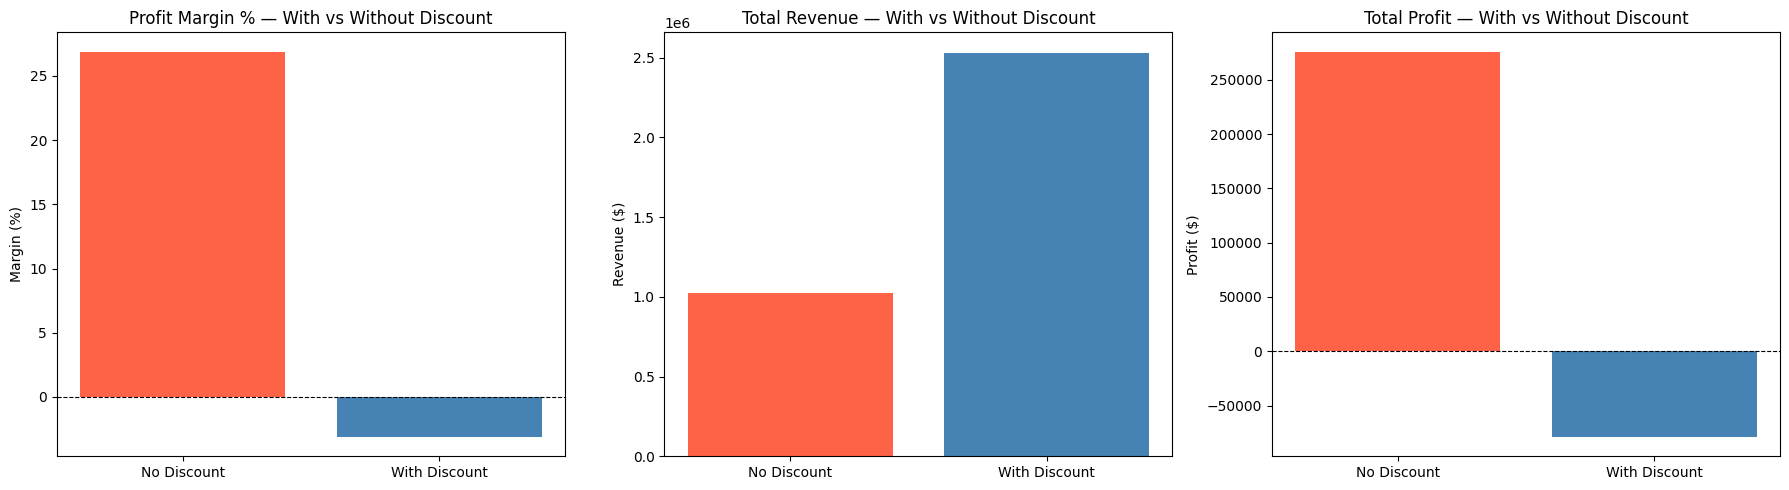

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(discount_compare.index, discount_compare['Margin_%'],
            color=['tomato', 'steelblue'])
axes[0].set_title('Profit Margin % — With vs Without Discount')
axes[0].set_ylabel('Margin (%)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[1].bar(discount_compare.index, discount_compare['Total_Revenue'],
            color=['tomato', 'steelblue'])
axes[1].set_title('Total Revenue — With vs Without Discount')
axes[1].set_ylabel('Revenue ($)')

axes[2].bar(discount_compare.index, discount_compare['Total_Profit'],
            color=['tomato', 'steelblue'])
axes[2].set_title('Total Profit — With vs Without Discount')
axes[2].set_ylabel('Profit ($)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

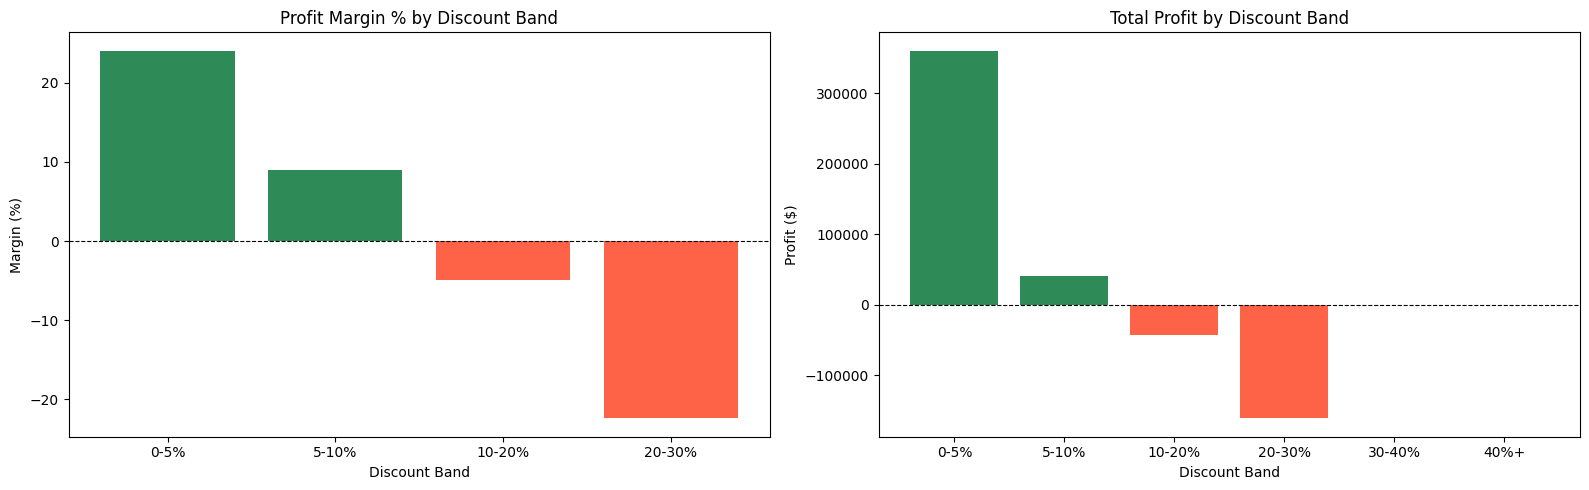

In [61]:
colors = ['seagreen' if m >= 0 else 'tomato' for m in band_summary['Margin_%']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(band_summary.index, band_summary['Margin_%'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Profit Margin % by Discount Band')
axes[0].set_xlabel('Discount Band')
axes[0].set_ylabel('Margin (%)')

axes[1].bar(band_summary.index, band_summary['Total_Profit'],
            color=['seagreen' if v >= 0 else 'tomato' for v in band_summary['Total_Profit']])
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Total Profit by Discount Band')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

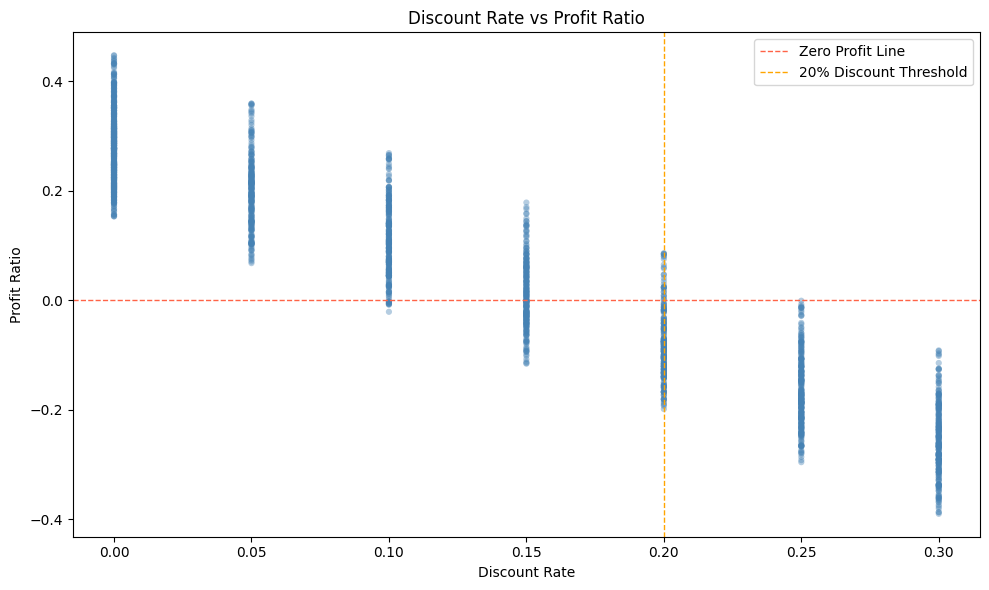

In [62]:
sample = df.sample(min(2000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['Order Item Discount Rate'], sample['Order Item Profit Ratio'],
            alpha=0.4, s=20, color='steelblue', edgecolors='none')
plt.axhline(0, color='tomato',  linewidth=1, linestyle='--', label='Zero Profit Line')
plt.axvline(0.2, color='orange', linewidth=1, linestyle='--', label='20% Discount Threshold')
plt.title('Discount Rate vs Profit Ratio')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Ratio')
plt.legend()
plt.tight_layout()
plt.show()

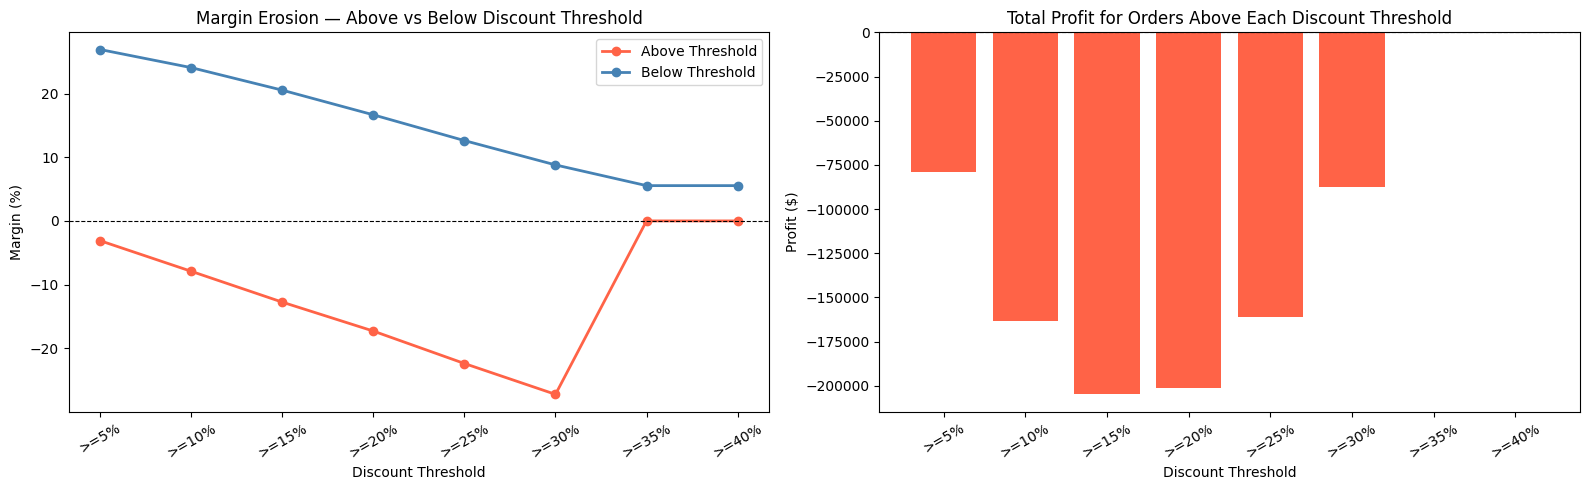

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(erosion_df['Threshold'], erosion_df['Margin_Above_%'],
             marker='o', color='tomato',   label='Above Threshold', linewidth=2)
axes[0].plot(erosion_df['Threshold'], erosion_df['Margin_Below_%'],
             marker='o', color='steelblue', label='Below Threshold', linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Margin Erosion — Above vs Below Discount Threshold')
axes[0].set_xlabel('Discount Threshold')
axes[0].set_ylabel('Margin (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(erosion_df['Threshold'], erosion_df['Profit_Above'],
            color=['tomato' if v < 0 else 'steelblue' for v in erosion_df['Profit_Above']])
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Total Profit for Orders Above Each Discount Threshold')
axes[1].set_xlabel('Discount Threshold')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

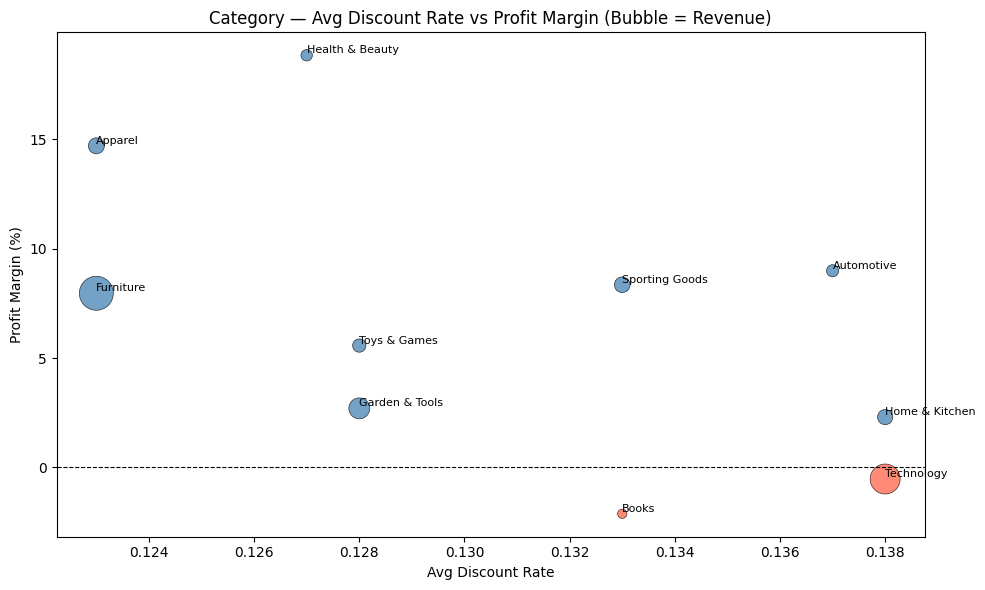

In [64]:
plt.figure(figsize=(10, 6))
colors = ['tomato' if m < 0 else 'steelblue' for m in cat_discount['Margin_%']]

plt.scatter(cat_discount['Avg_Discount_Rate'], cat_discount['Margin_%'],
            s=cat_discount['Total_Revenue'] / cat_discount['Total_Revenue'].max() * 600,
            color=colors, alpha=0.75, edgecolors='black', linewidth=0.5)

for i, row in cat_discount.iterrows():
    plt.annotate(i, (row['Avg_Discount_Rate'], row['Margin_%']),
                 fontsize=8, ha='left', va='bottom')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Category — Avg Discount Rate vs Profit Margin (Bubble = Revenue)')
plt.xlabel('Avg Discount Rate')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

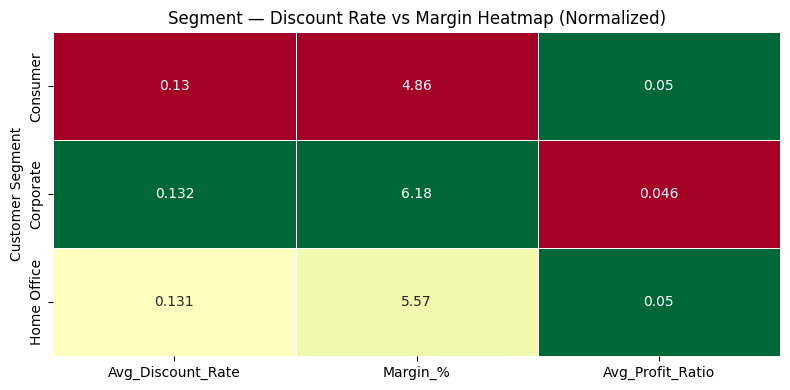

In [65]:
heat_data = seg_discount[['Avg_Discount_Rate', 'Margin_%', 'Avg_Profit_Ratio']].copy()

plt.figure(figsize=(8, 4))
sns.heatmap(
    heat_data.apply(lambda x: (x - x.min()) / (x.max() - x.min())),
    annot=heat_data.round(3),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar=False
)
plt.title('Segment — Discount Rate vs Margin Heatmap (Normalized)')
plt.tight_layout()
plt.show()

In [66]:
market_summary = df.groupby('Market').agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(2)

market_summary['Margin_%'] = (market_summary['Total_Profit'] / market_summary['Total_Revenue'] * 100).round(2)
market_summary = market_summary.sort_values('Total_Profit', ascending=False)
print(market_summary)

              Total_Revenue  Total_Profit  Orders  Avg_Discount_Rate  \
Market                                                                 
Africa            836238.14      53260.32    1066               0.13   
Pacific Asia      739954.98      49248.07    1091               0.13   
LATAM             669976.89      35783.80     971               0.13   
USCA              703551.95      35231.05     950               0.13   
Europe            609248.26      23480.39     922               0.13   

              Avg_Profit_Ratio  Margin_%  
Market                                    
Africa                    0.05      6.37  
Pacific Asia              0.05      6.66  
LATAM                     0.05      5.34  
USCA                      0.05      5.01  
Europe                    0.05      3.85  


In [67]:
region_summary = df.groupby('Order Region').agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).round(2)

region_summary['Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Revenue'] * 100).round(2)
region_summary = region_summary.sort_values('Total_Profit', ascending=False)
print(region_summary)

                 Total_Revenue  Total_Profit  Orders  Avg_Discount_Rate  \
Order Region                                                              
North America        703551.95      35231.05     950               0.13   
West Africa          340191.82      29563.08     394               0.13   
South America        371258.96      19781.56     495               0.13   
East Asia            214371.00      17167.36     359               0.13   
Western Europe       232672.03      16968.42     308               0.12   
South Asia           238622.67      16207.35     377               0.13   
Central America      298717.93      16002.24     476               0.13   
Oceania              286961.31      15873.36     355               0.13   
South Africa         232506.02      14306.49     319               0.13   
East Africa          263540.30       9390.75     353               0.14   
Northern Europe      170413.60       3414.75     275               0.13   
Southern Europe      2061

In [68]:
country_summary = df.groupby('Order Country').agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount_Rate=('Order Item Discount Rate', 'mean')
).round(2)

country_summary['Margin_%'] = (country_summary['Total_Profit'] / country_summary['Total_Revenue'] * 100).round(2)
country_summary = country_summary.sort_values('Total_Profit', ascending=False)
print("Total Countries:", len(country_summary))
print(country_summary.head(20))

Total Countries: 22
                Total_Revenue  Total_Profit  Orders  Avg_Discount_Rate  \
Order Country                                                            
Canada              371717.54      24810.31     471               0.13   
Ghana               162075.64      16482.63     225               0.12   
China               139707.70      14199.38     222               0.13   
Chile               160204.20      12219.89     215               0.12   
Kenya               156298.24      11692.16     194               0.13   
Mexico              137715.90      11232.47     191               0.12   
United States       331834.41      10420.74     479               0.14   
Japan               156357.40      10070.38     213               0.13   
Italy               131245.03       9835.86     203               0.12   
South Africa        140023.81       8993.93     196               0.13   
Australia           171695.87       8802.84     229               0.12   
Nigeria           

In [69]:
loss_markets = market_summary[market_summary['Total_Profit'] < 0]
loss_regions = region_summary[region_summary['Total_Profit'] < 0]

print("Loss-Making Markets:")
print(loss_markets[['Total_Revenue', 'Total_Profit', 'Margin_%']])
print()
print("Loss-Making Regions:")
print(loss_regions[['Total_Revenue', 'Total_Profit', 'Margin_%']])

Loss-Making Markets:
Empty DataFrame
Columns: [Total_Revenue, Total_Profit, Margin_%]
Index: []

Loss-Making Regions:
Empty DataFrame
Columns: [Total_Revenue, Total_Profit, Margin_%]
Index: []


In [70]:
rev_threshold_m = market_summary['Total_Revenue'].quantile(0.50)
margin_threshold_m = 5

weak_profit_markets = market_summary[
    (market_summary['Total_Revenue'] >= rev_threshold_m) &
    (market_summary['Margin_%'] < margin_threshold_m)
].sort_values('Total_Revenue', ascending=False)

print("Strong Revenue but Weak Profit Markets:")
print(weak_profit_markets[['Total_Revenue', 'Total_Profit', 'Margin_%', 'Avg_Discount_Rate']])

Strong Revenue but Weak Profit Markets:
Empty DataFrame
Columns: [Total_Revenue, Total_Profit, Margin_%, Avg_Discount_Rate]
Index: []


In [71]:
rev_threshold_r = region_summary['Total_Revenue'].quantile(0.50)

weak_profit_regions = region_summary[
    (region_summary['Total_Revenue'] >= rev_threshold_r) &
    (region_summary['Margin_%'] < margin_threshold_m)
].sort_values('Total_Revenue', ascending=False)

print("Strong Revenue but Weak Profit Regions:")
print(weak_profit_regions[['Total_Revenue', 'Total_Profit', 'Margin_%', 'Avg_Discount_Rate']])

Strong Revenue but Weak Profit Regions:
              Total_Revenue  Total_Profit  Margin_%  Avg_Discount_Rate
Order Region                                                          
East Africa        263540.3       9390.75      3.56               0.14


In [72]:
top10_countries    = country_summary.sort_values('Total_Profit', ascending=False).head(10)
bottom10_countries = country_summary.sort_values('Total_Profit').head(10)

print("Top 10 Countries by Profit:")
print(top10_countries[['Total_Revenue', 'Total_Profit', 'Margin_%']])
print()
print("Bottom 10 Countries by Profit:")
print(bottom10_countries[['Total_Revenue', 'Total_Profit', 'Margin_%']])

Top 10 Countries by Profit:
               Total_Revenue  Total_Profit  Margin_%
Order Country                                       
Canada             371717.54      24810.31      6.67
Ghana              162075.64      16482.63     10.17
China              139707.70      14199.38     10.16
Chile              160204.20      12219.89      7.63
Kenya              156298.24      11692.16      7.48
Mexico             137715.90      11232.47      8.16
United States      331834.41      10420.74      3.14
Japan              156357.40      10070.38      6.44
Italy              131245.03       9835.86      7.49
South Africa       140023.81       8993.93      6.42

Bottom 10 Countries by Profit:
                Total_Revenue  Total_Profit  Margin_%
Order Country                                        
Argentina           109068.61       -307.98     -0.28
Germany              99893.26       1042.05      1.04
United Kingdom      135379.74       2152.06      1.59
France              129041.30     

In [73]:
market_region_pivot = df.groupby(['Market', 'Order Region'])['Order Profit Per Order'].sum().round(2).unstack(fill_value=0)
print(market_region_pivot)

Order Region  Central America  East Africa  East Asia  North America  \
Market                                                                 
Africa                   0.00      9390.75       0.00           0.00   
Europe                   0.00         0.00       0.00           0.00   
LATAM                16002.24         0.00       0.00           0.00   
Pacific Asia             0.00         0.00   17167.36           0.00   
USCA                     0.00         0.00       0.00       35231.05   

Order Region  Northern Europe   Oceania  South Africa  South America  \
Market                                                                 
Africa                   0.00      0.00      14306.49           0.00   
Europe                3414.75      0.00          0.00           0.00   
LATAM                    0.00      0.00          0.00       19781.56   
Pacific Asia             0.00  15873.36          0.00           0.00   
USCA                     0.00      0.00          0.00          

In [74]:
loss_countries = country_summary[country_summary['Total_Profit'] < 0].sort_values('Total_Profit')

print("Total Loss-Making Countries:", len(loss_countries))
print("Total Loss Amount          :", loss_countries['Total_Profit'].sum().round(2))
print()
print(loss_countries[['Total_Revenue', 'Total_Profit', 'Margin_%', 'Avg_Discount_Rate']].head(15))

Total Loss-Making Countries: 1
Total Loss Amount          : -307.98

               Total_Revenue  Total_Profit  Margin_%  Avg_Discount_Rate
Order Country                                                          
Argentina          109068.61       -307.98     -0.28               0.14


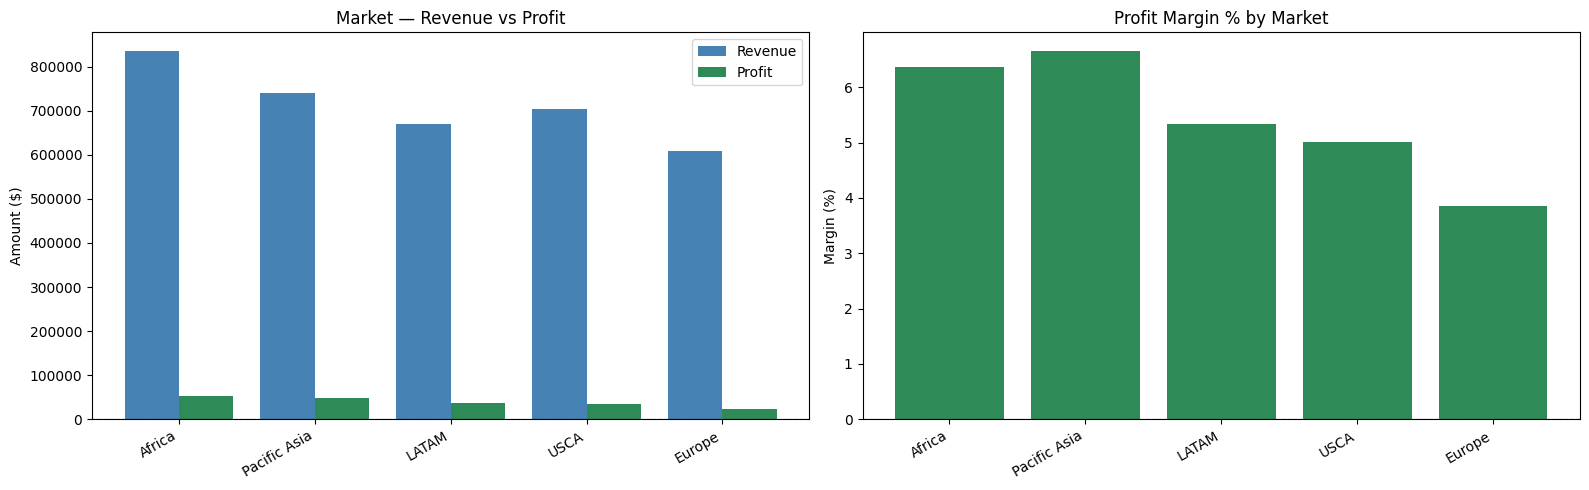

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(market_summary))
width = 0.4

axes[0].bar([i - width/2 for i in x], market_summary['Total_Revenue'], width=width, label='Revenue', color='steelblue')
axes[0].bar([i + width/2 for i in x], market_summary['Total_Profit'],  width=width, label='Profit',
            color=['seagreen' if v >= 0 else 'tomato' for v in market_summary['Total_Profit']])
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(market_summary.index, rotation=30, ha='right')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Market — Revenue vs Profit')
axes[0].set_ylabel('Amount ($)')
axes[0].legend()

axes[1].bar(market_summary.index, market_summary['Margin_%'],
            color=['seagreen' if m >= 0 else 'tomato' for m in market_summary['Margin_%']])
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Profit Margin % by Market')
axes[1].set_ylabel('Margin (%)')
axes[1].set_xticklabels(market_summary.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()

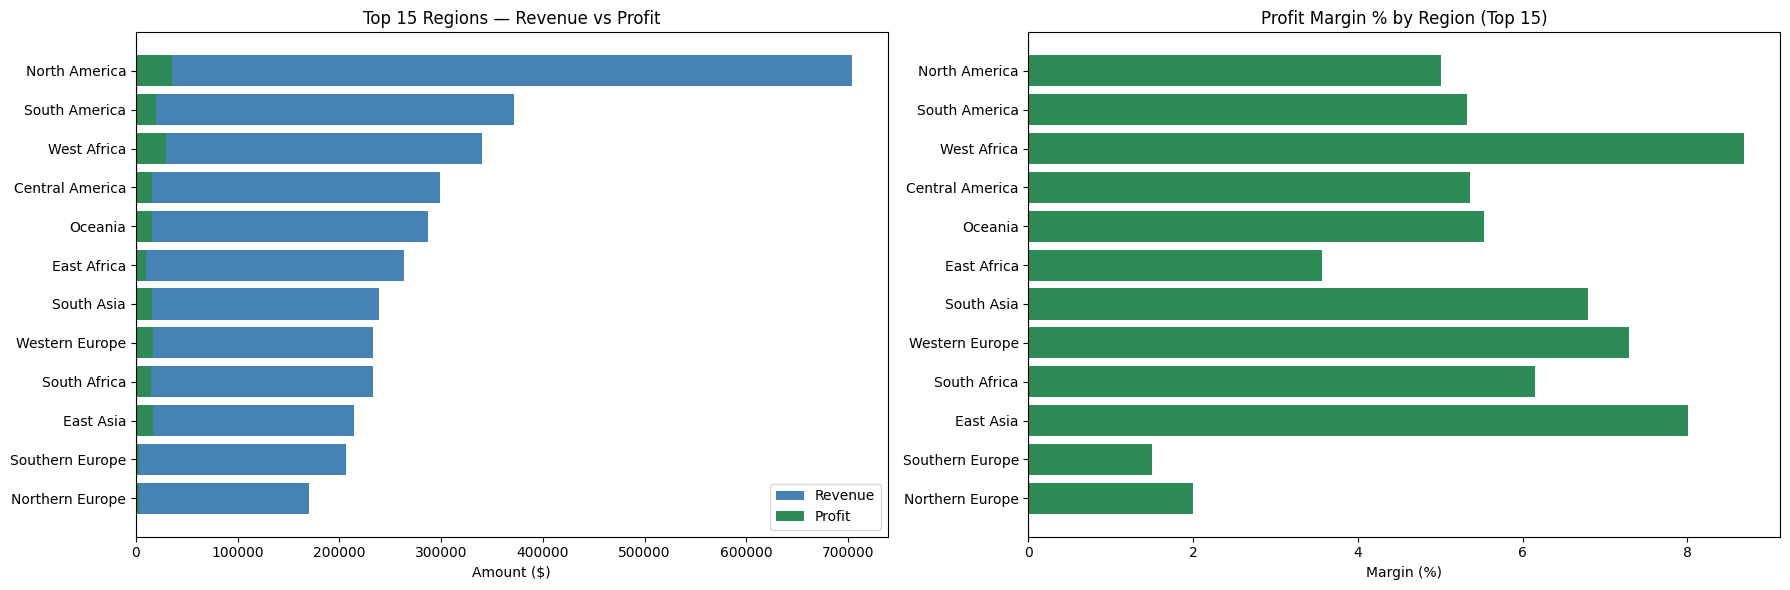

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_regions = region_summary.sort_values('Total_Revenue', ascending=False).head(15)

axes[0].barh(top_regions.index, top_regions['Total_Revenue'], color='steelblue', label='Revenue')
axes[0].barh(top_regions.index, top_regions['Total_Profit'],
             color=['seagreen' if v >= 0 else 'tomato' for v in top_regions['Total_Profit']], label='Profit')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Top 15 Regions — Revenue vs Profit')
axes[0].set_xlabel('Amount ($)')
axes[0].invert_yaxis()
axes[0].legend()

axes[1].barh(top_regions.index, top_regions['Margin_%'],
             color=['seagreen' if m >= 0 else 'tomato' for m in top_regions['Margin_%']])
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Profit Margin % by Region (Top 15)')
axes[1].set_xlabel('Margin (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

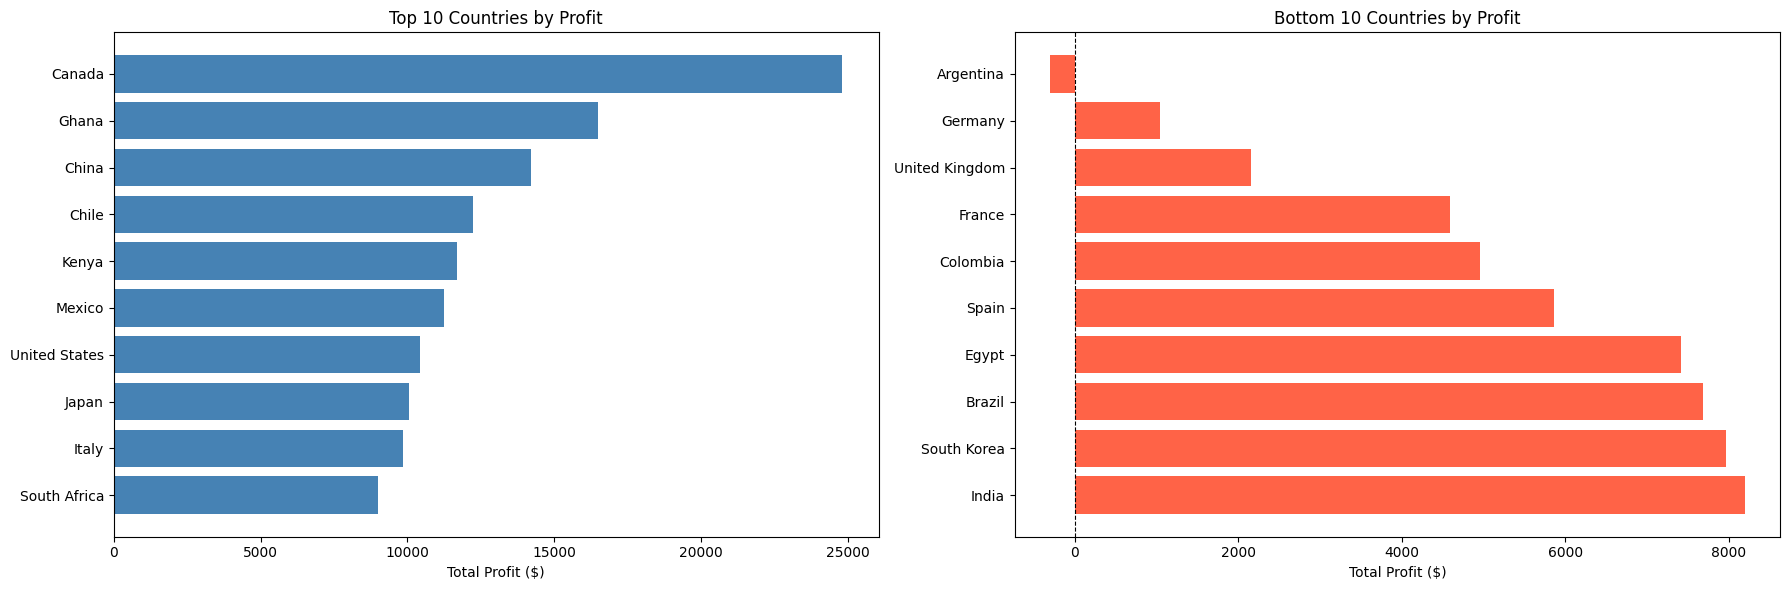

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top10_countries.index, top10_countries['Total_Profit'], color='steelblue')
axes[0].set_title('Top 10 Countries by Profit')
axes[0].set_xlabel('Total Profit ($)')
axes[0].invert_yaxis()

axes[1].barh(bottom10_countries.index, bottom10_countries['Total_Profit'], color='tomato')
axes[1].set_title('Bottom 10 Countries by Profit')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

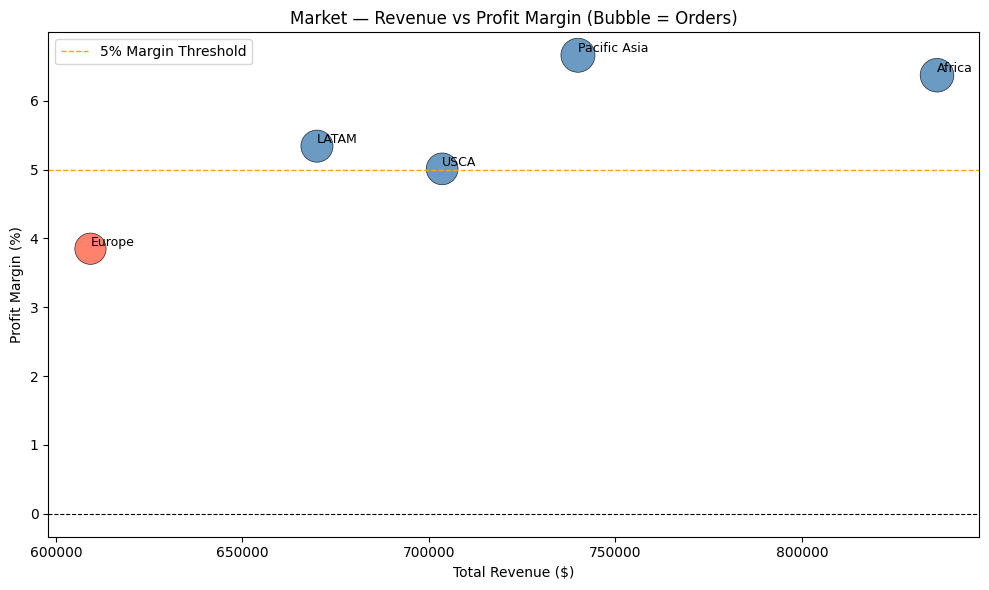

In [77]:
plt.figure(figsize=(10, 6))
colors = ['tomato' if m < 5 else 'steelblue' for m in market_summary['Margin_%']]

plt.scatter(market_summary['Total_Revenue'], market_summary['Margin_%'],
            s=market_summary['Orders'] / market_summary['Orders'].max() * 600,
            color=colors, alpha=0.8, edgecolors='black', linewidth=0.5)

for i, row in market_summary.iterrows():
    plt.annotate(i, (row['Total_Revenue'], row['Margin_%']), fontsize=9, ha='left', va='bottom')

plt.axhline(5, color='orange', linewidth=1, linestyle='--', label='5% Margin Threshold')
plt.axhline(0, color='black',  linewidth=0.8, linestyle='--')
plt.title('Market — Revenue vs Profit Margin (Bubble = Orders)')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Profit Margin (%)')
plt.legend()
plt.tight_layout()
plt.show()

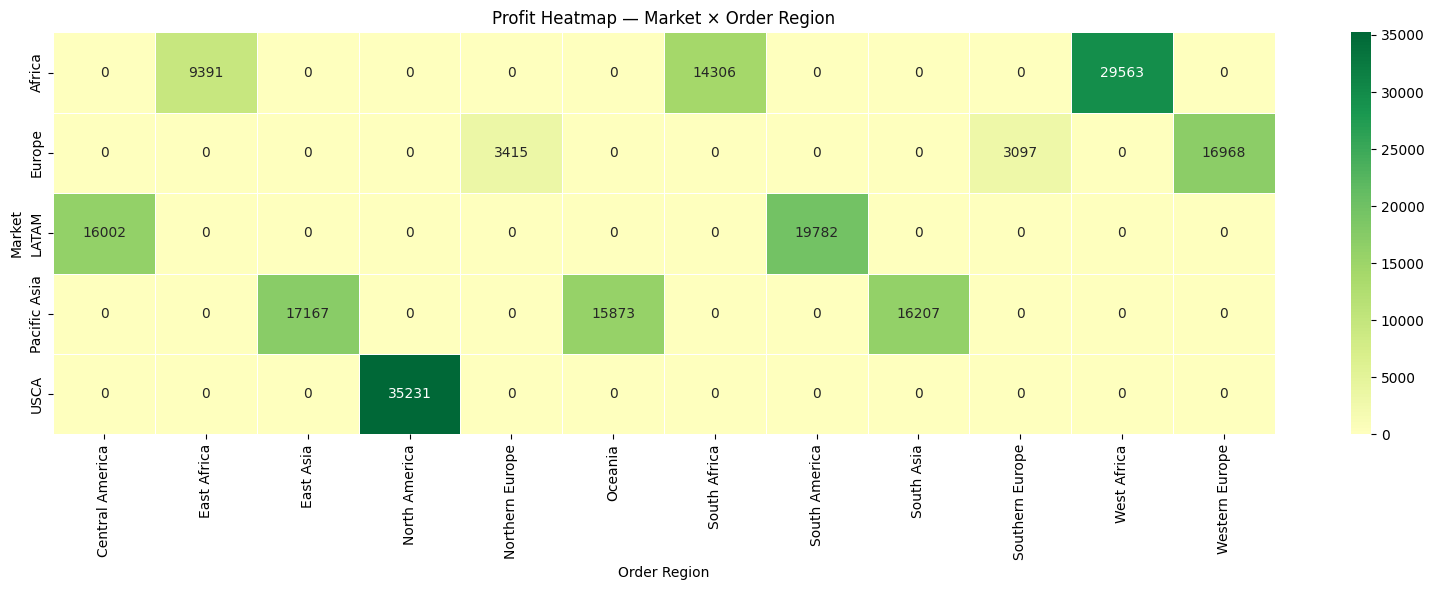

In [78]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    market_region_pivot,
    cmap='RdYlGn',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    center=0
)
plt.title('Profit Heatmap — Market × Order Region')
plt.xlabel('Order Region')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

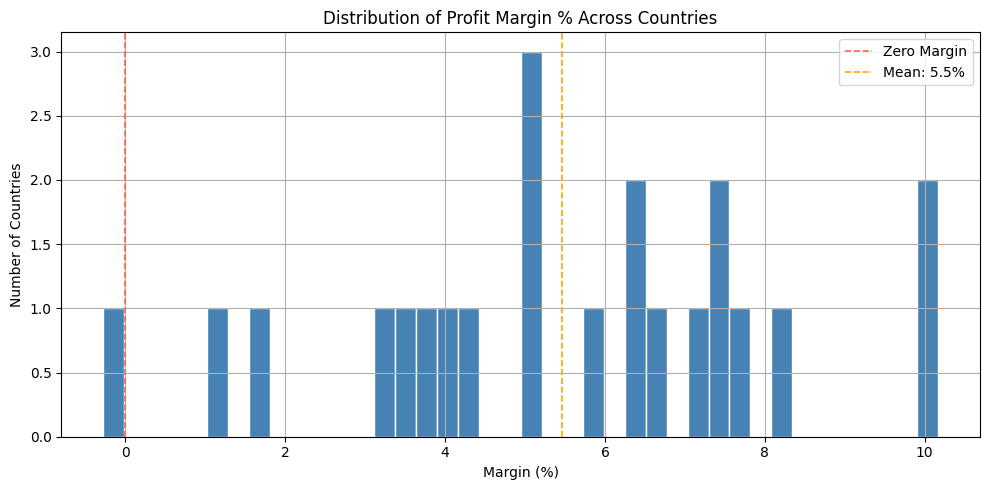

In [79]:
plt.figure(figsize=(10, 5))
country_summary['Margin_%'].clip(-50, 50).hist(bins=40, color='steelblue', edgecolor='white')
plt.axvline(0, color='tomato', linewidth=1.2, linestyle='--', label='Zero Margin')
plt.axvline(country_summary['Margin_%'].mean(), color='orange', linewidth=1.2, linestyle='--', label=f"Mean: {country_summary['Margin_%'].mean():.1f}%")
plt.title('Distribution of Profit Margin % Across Countries')
plt.xlabel('Margin (%)')
plt.ylabel('Number of Countries')
plt.legend()
plt.tight_layout()
plt.show()

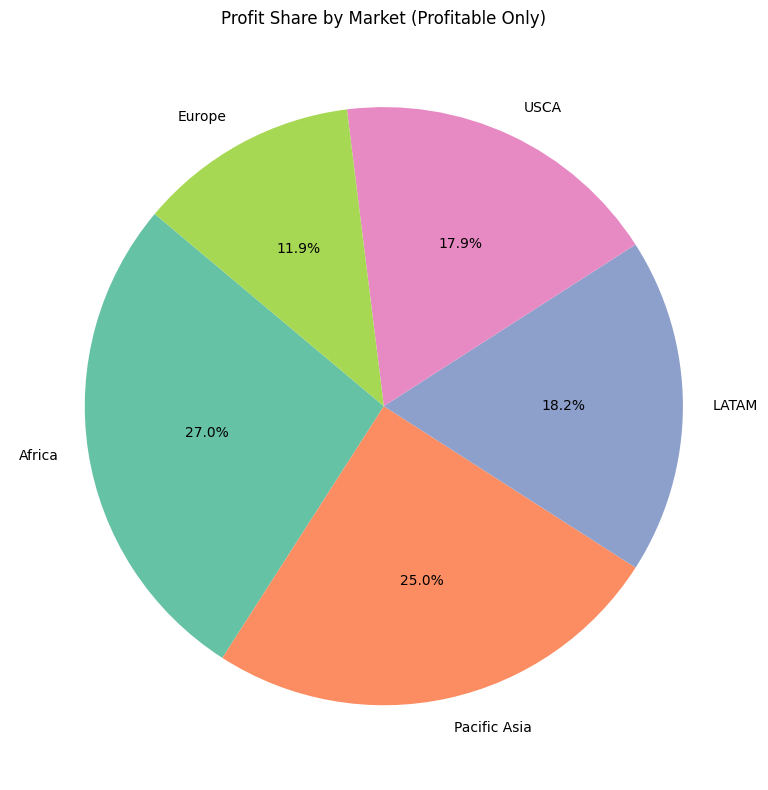

In [80]:
pos_markets = market_summary[market_summary['Total_Profit'] > 0]

plt.figure(figsize=(8, 8))
plt.pie(
    pos_markets['Total_Profit'],
    labels=pos_markets.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(pos_markets))
)
plt.title('Profit Share by Market (Profitable Only)')
plt.tight_layout()
plt.show()